In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Se lee el P_LUX
ruta_lux = '/content/drive/MyDrive/TFM/P_LUX.xpt'
lux = pd.read_sas(ruta_lux, format='xport')

# Se verifica forma y primeras filas: cuantas personas y con que columnas venimos
print(f'shape: {lux.shape}')
lux.head()

shape: (10409, 13)


,SEQN,LUAXSTAT,LUARXNC,LUARXND,LUARXIN,LUAPNME,LUANMVGP,LUANMTGP,LUXSMED,LUXSIQR,LUXSIQRM,LUXCAPM,LUXCPIQR
0,109264.0,3.0,NaN,NaN,2.0,b'',NaN,5.397605e-79,NaN,NaN,NaN,NaN,NaN
1,109266.0,1.0,NaN,NaN,NaN,b'XL',10.0,2.000000e+01,6.4,1.0,15.6,277.0,45.0
2,109271.0,1.0,NaN,NaN,NaN,b'XL',10.0,1.000000e+01,5.5,0.6,10.9,303.0,30.0
3,109273.0,1.0,NaN,NaN,NaN,b'M',10.0,1.000000e+01,2.7,0.7,25.9,222.0,65.0
4,109274.0,1.0,NaN,NaN,NaN,b'M',12.0,1.200000e+01,4.4,0.6,13.6,279.0,28.0


Cargué el archivo P_LUX de NHANES, que contiene los resultados del FibroScan de cada persona. Cada fila es un individuo (identificado por su SEQN) y las columnas son las medidas del examen. La que me interesa es LUXCAPM: el CAP en dB/m, que cuantifica la grasa en el hígado y es la variable que quiero predecir. Al mirar las primeras filas confirmé que el archivo cargó bien y que el target trae valores creíbles (por ejemplo 277, 303, 222 dB/m).

En esa misma inspección noté algo importante: no a todos los examinados se les pudo medir el CAP. La columna LUAXSTAT indica el estado del examen (el valor 1 es un examen válido; otros códigos significan que quedó incompleto), y en esas filas el LUXCAPM viene vacío. Por eso decidí que mi universo de modelado se quedaría solo con las filas que tienen CAP válido: sin un valor de grasa hepática medido, no hay nada que predecir.

In [ ]:
# Se separa el universo modelable: sin LUXCAPM medido no hay target, no hay caso
total = len(lux)
validos = lux['LUXCAPM'].notna().sum()
faltantes = lux['LUXCAPM'].isna().sum()

print('--- Disponibilidad del target (CAP) ---')
print(f'{"Filas totales en P_LUX":<32}: {total:>6,}')
print(f'{"Con CAP valido (LUXCAPM)":<32}: {validos:>6,}')
print(f'{"Sin CAP (examen no valido)":<32}: {faltantes:>6,}  ({faltantes/total*100:.1f}%)')

# Se describe la distribucion del CAP solo sobre los casos validos
cap = lux['LUXCAPM'].dropna()

print('\n--- Distribucion del CAP (dB/m) ---')
print(f'{"media":<10}: {cap.mean():>6.1f}')
print(f'{"mediana":<10}: {cap.median():>6.1f}')
print(f'{"minimo":<10}: {cap.min():>6.1f}')
print(f'{"maximo":<10}: {cap.max():>6.1f}')

# Se aplica el corte clinico para leer la prevalencia de esteatosis en la muestra
umbral_esteatosis = 285
prevalencia = (cap >= umbral_esteatosis).mean() * 100
print(f'\nPrevalencia esteatosis (CAP >= {umbral_esteatosis}): {prevalencia:.1f}%')

--- Disponibilidad del target (CAP) ---
Filas totales en P_LUX          : 10,409
Con CAP valido (LUXCAPM)        :  9,698
Sin CAP (examen no valido)      :    711  (6.8%)

--- Distribucion del CAP (dB/m) ---
media     :  257.6
mediana   :  253.0
minimo    :  100.0
maximo    :  400.0

Prevalencia esteatosis (CAP >= 285): 33.2%


In [ ]:
# Se trae DEMO (edad y sexo): P_LUX incluye mayores de 12, pero la MASLD y el modelo se definen sobre adultos (>=20), y la edad vive en el archivo de demografia
ruta_demo = '/content/drive/MyDrive/TFM/P_DEMO.xpt'
demo = pd.read_sas(ruta_demo, format='xport')[['SEQN', 'RIDAGEYR', 'RIAGENDR']]

# Se une elastografia con demografia por SEQN (nuestro primer merge: una fila por persona)
base = lux[['SEQN', 'LUXCAPM']].merge(demo, on='SEQN', how='left')

# Se define el universo de modelado: adultos >=20 con CAP valido
universo = base[(base['RIDAGEYR'] >= 20) & (base['LUXCAPM'].notna())].copy()

print('--- Universo de modelado (adultos con CAP valido) ---')
print(f'{"Adultos >=20 con CAP valido":<34}: {len(universo):>6,}')

cap = universo['LUXCAPM']
print(f'{"media CAP":<34}: {cap.mean():>6.1f}')
print(f'{"prevalencia esteatosis (>=285)":<34}: {(cap >= 285).mean()*100:>5.1f}%')

--- Universo de modelado (adultos con CAP valido) ---
Adultos >=20 con CAP valido       :  7,922
media CAP                         :  265.5
prevalencia esteatosis (>=285)    :  37.9%


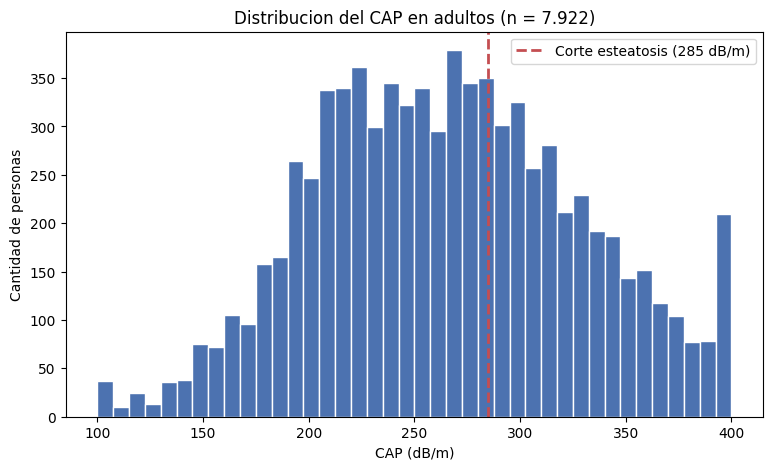

In [ ]:
import matplotlib.pyplot as plt

# Se visualiza la forma de la distribucion del CAP: los resumenes numericos no muestran picos, colas ni el amontonamiento en los topes del aparato (100 y 400 dB/m)
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(universo['LUXCAPM'], bins=40, color='#4C72B0', edgecolor='white')

# Se marca el corte clinico de esteatosis para leer visualmente el balance de clases
ax.axvline(285, color='#C44E52', linestyle='--', linewidth=2, label='Corte esteatosis (285 dB/m)')

ax.set_title('Distribucion del CAP en adultos (n = 7.922)')
ax.set_xlabel('CAP (dB/m)')
ax.set_ylabel('Cantidad de personas')
ax.legend()
plt.show()

Miré la forma de la distribución del CAP. El histograma muestra una distribución unimodal y aproximadamente simétrica, centrada en ~250-270 dB/m, lo que respalda mi enfoque de regresión sobre una variable continua bien comportada. El corte clínico de 285 dB/m deja una masa considerable a ambos lados, consistente con la prevalencia del 37,9% y un buen balance de clases.

Observé además una acumulación anómala de casos en el valor máximo de 400 dB/m: es la censura por la derecha propia del FibroScan, que no mide por encima de ese tope y colapsa en él toda la esteatosis severa. Esta es una limitación de la medición, no del modelo, y es una de las razones estructurales del techo de R² moderado que anticipé; la documento como tal.

# Fase 2 — Merge de bases y armado de la cohorte

En esta fase construí el dataset de trabajo. Para cada ciclo uní por `SEQN` los módulos que seleccioné (target, demografía, dieta, antropometría, presión, laboratorio y estilo de vida), apilé los dos ciclos, y recién sobre el conjunto completo apliqué los filtros de cohorte y las exclusiones. Trabajé primero el ciclo 2017-2020 para validar la mecánica, y después repliqué con el 2021-2023.

### Armado del esqueleto — merge de target y demografía

Inicié el dataset uniendo por `SEQN` la demografía (`P_DEMO`, edad y sexo) con la elastografía (`P_LUX`, mi target). Usé un `left join` desde la demografía para conservar a todos los encuestados y pegarles el CAP a quienes lo tuvieran.

Los números confirman que salió bien: la demografía trae 15.560 personas y la elastografía 10.409 (menos, porque no a todos se les midió el CAP). La tabla resultante mantiene las 15.560 filas y suma la columna del target. Como esperaba, varios participantes quedan con `LUXCAPM` vacío (menores o exámenes no válidos), mientras que el adulto de 29 años sí registra un CAP de 277 dB/m. Esos vacíos son esperables y los filtraré al definir la cohorte, quedándome solo con adultos con CAP válido.

In [ ]:
import pandas as pd

# Se define la carpeta del ciclo 2017-2020 en Drive
RUTA_2017 = '/content/drive/MyDrive/TFM/Nhanes 2017-2020/'

# Se centraliza la lectura indicando subcarpeta y archivo (respeta el orden por componente)
def leer(subcarpeta, nombre_archivo):
    df = pd.read_sas(f'{RUTA_2017}{subcarpeta}/{nombre_archivo}.xpt', format='xport')
    df['SEQN'] = df['SEQN'].astype('int64')
    return df

# Se cargan los dos archivos del esqueleto: target (LUX) y demografia (DEMO)
lux = leer('Examination', 'P_LUX')[['SEQN', 'LUXCAPM']]
demo = leer('Demography', 'P_DEMO')[['SEQN', 'RIDAGEYR', 'RIAGENDR']]

# Se une el esqueleto por SEQN: partimos de demografia y le pegamos el target
base = demo.merge(lux, on='SEQN', how='left')

print(f'demo : {demo.shape}')
print(f'lux  : {lux.shape}')
print(f'base : {base.shape}')
base.head()

demo : (15560, 3)
lux  : (10409, 2)
base : (15560, 4)


,SEQN,RIDAGEYR,RIAGENDR,LUXCAPM
0,109263,2.0,1.0,NaN
1,109264,13.0,2.0,NaN
2,109265,2.0,1.0,NaN
3,109266,29.0,2.0,277.0
4,109267,21.0,2.0,NaN


### Módulo 1 — Antropometría

Colgué el primer módulo de predictores: la antropometría (`P_BMX`), de donde saldrá el **WHtR** (cintura/talla), el mejor predictor antropométrico de adiposidad central y uno de los índices centrales de mi modelo. Tomé peso, talla, cintura e IMC, sumando el IMC como referencia clásica para compararlo después contra el WHtR.

El módulo se unió sin pérdidas: la base mantiene sus 15.560 filas y ahora tiene 8 columnas. Verifiqué la variable clave, la cintura (`BMXWAIST`): está medida en 12.574 de 15.560 personas. Los faltantes se concentran en menores y en participantes sin CAP válido, así que espero que se reduzcan solos al filtrar la cohorte de adultos. Lo reevaluaré sobre la cohorte final, que es donde el dato realmente importa.

Mantengo un criterio en toda esta fase: solo uno los módulos crudos. Los índices derivados (WHtR, DII, TyG) los construyo más adelante, en la fase de feature engineering, para separar la etapa de integración de la de transformación.

In [ ]:
# Se carga antropometria: peso, talla y cintura -> base para el WHtR (cintura/talla)
# BMXWT=peso(kg), BMXHT=talla(cm), BMXWAIST=cintura(cm), BMXBMI=IMC
bmx = leer('Examination', 'P_BMX')[['SEQN', 'BMXWT', 'BMXHT', 'BMXWAIST', 'BMXBMI']]

# Se cuelga la antropometria al esqueleto por SEQN
base = base.merge(bmx, on='SEQN', how='left')

print(f'bmx  : {bmx.shape}')
print(f'base : {base.shape}')

# Se verifica cuantos tienen la cintura medida (clave para el WHtR)
tiene_cintura = base['BMXWAIST'].notna().sum()
print(f'\nCon cintura (BMXWAIST) medida: {tiene_cintura:,} de {len(base):,}')
base.head()

bmx  : (14300, 5)
base : (15560, 8)

Con cintura (BMXWAIST) medida: 12,574 de 15,560


,SEQN,RIDAGEYR,RIAGENDR,LUXCAPM,BMXWT,BMXHT,BMXWAIST,BMXBMI
0,109263,2.0,1.0,NaN,NaN,NaN,NaN,NaN
1,109264,13.0,2.0,NaN,42.2,154.7,63.8,17.6
2,109265,2.0,1.0,NaN,12.0,89.3,41.2,15.0
3,109266,29.0,2.0,277.0,97.1,160.2,117.9,37.8
4,109267,21.0,2.0,NaN,NaN,NaN,NaN,NaN


### Módulo 2 — Presión arterial

Sumé la presión arterial (`P_BPXO`, medición oscilométrica), de donde derivaré la **presión de pulso** (sistólica − diastólica), un marcador de rigidez arterial vinculado al riesgo metabólico. Tomé las lecturas sistólica y diastólica; como NHANES realiza varias tomas por persona, me quedé con la primera de cada una. Colgué el módulo por `SEQN` con un `left join`, manteniendo la base intacta.

In [ ]:
# Se carga la presion arterial oscilometrica -> base para la presion de pulso (sist - diast)
# BPXOSY1 = sistolica (1a lectura), BPXODI1 = diastolica (1a lectura)
bpxo = leer('Examination', 'P_BPXO')[['SEQN', 'BPXOSY1', 'BPXODI1']]

# Se cuelga la presion al esqueleto por SEQN
base = base.merge(bpxo, on='SEQN', how='left')

print(f'bpxo : {bpxo.shape}')
print(f'base : {base.shape}')

# Se verifica cuantos tienen la presion sistolica medida
tiene_presion = base['BPXOSY1'].notna().sum()
print(f'\nCon presion (BPXOSY1) medida: {tiene_presion:,} de {len(base):,}')
base.head()

bpxo : (11656, 3)
base : (15560, 10)

Con presion (BPXOSY1) medida: 10,352 de 15,560


,SEQN,RIDAGEYR,RIAGENDR,LUXCAPM,BMXWT,BMXHT,BMXWAIST,BMXBMI,BPXOSY1,BPXODI1
0,109263,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,109264,13.0,2.0,NaN,42.2,154.7,63.8,17.6,109.0,67.0
2,109265,2.0,1.0,NaN,12.0,89.3,41.2,15.0,NaN,NaN
3,109266,29.0,2.0,277.0,97.1,160.2,117.9,37.8,99.0,56.0
4,109267,21.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Módulo 3 — Dieta (recordatorios de 24h) y base del DII

Llegué al módulo central del proyecto: la dieta. De acá saldrá el **DII (Dietary Inflammatory Index)**, el índice que cuantifica el potencial inflamatorio de la alimentación y que, en mi hipótesis inicial, era el predictor de mayor peso teórico, por ser la dieta un mecanismo causal directo de la acumulación de grasa hepática.

NHANES releva la dieta mediante dos recordatorios de 24 horas por persona (día 1 y día 2), en archivos separados (`P_DR1TOT` y `P_DR2TOT`). Cada archivo trae más de cien columnas (una por nutriente), así que antes de mergear exploré el contenido para seleccionar únicamente los nutrientes que alimentan el DII y mis predictores dietéticos, descartando el resto. Este primer paso es solo exploratorio: listo las columnas del día 1 para decidir, con criterio clínico, cuáles conservar.

In [ ]:
# Se carga el dia 1 de dieta para explorar que columnas de nutrientes trae
dr1 = leer('Dietary Data', 'P_DR1TOT')

print(f'dr1 : {dr1.shape}')

# Se filtran las columnas de nutrientes relevantes para el DII y predictores dieteticos
# En NHANES los totales del dia 1 empiezan con 'DR1T'
cols_nutrientes = [c for c in dr1.columns if c.startswith('DR1T')]
print(f'\nColumnas de nutrientes (DR1T...): {len(cols_nutrientes)}')
for c in cols_nutrientes:
    print(f'  {c}')

dr1 : (14300, 168)

Columnas de nutrientes (DR1T...): 67
  DR1TNUMF
  DR1TKCAL
  DR1TPROT
  DR1TCARB
  DR1TSUGR
  DR1TFIBE
  DR1TTFAT
  DR1TSFAT
  DR1TMFAT
  DR1TPFAT
  DR1TCHOL
  DR1TATOC
  DR1TATOA
  DR1TRET
  DR1TVARA
  DR1TACAR
  DR1TBCAR
  DR1TCRYP
  DR1TLYCO
  DR1TLZ
  DR1TVB1
  DR1TVB2
  DR1TNIAC
  DR1TVB6
  DR1TFOLA
  DR1TFA
  DR1TFF
  DR1TFDFE
  DR1TCHL
  DR1TVB12
  DR1TB12A
  DR1TVC
  DR1TVD
  DR1TVK
  DR1TCALC
  DR1TPHOS
  DR1TMAGN
  DR1TIRON
  DR1TZINC
  DR1TCOPP
  DR1TSODI
  DR1TPOTA
  DR1TSELE
  DR1TCAFF
  DR1TTHEO
  DR1TALCO
  DR1TMOIS
  DR1TS040
  DR1TS060
  DR1TS080
  DR1TS100
  DR1TS120
  DR1TS140
  DR1TS160
  DR1TS180
  DR1TM161
  DR1TM181
  DR1TM201
  DR1TM221
  DR1TP182
  DR1TP183
  DR1TP184
  DR1TP204
  DR1TP205
  DR1TP225
  DR1TP226
  DR1TWSZ


### Selección de nutrientes y promedio de los dos días

De los 67 nutrientes disponibles en cada recordatorio seleccioné los ~27 que componen el DII: macronutrientes y energía, vitaminas, minerales y bioactivos. La selección no es arbitraria: responde a la lista de componentes que el índice inflamatorio requiere.

Para reducir el ruido intra-individual (un solo día puede no representar la dieta habitual), promedié el día 1 y el día 2 de cada persona, nutriente por nutriente. Usé un `outer join` entre ambos días y un promedio que tolera faltantes: si alguien completó un solo recordatorio, conservo ese valor en lugar de descartarlo, rescatando así a los participantes con un único día válido.

El módulo se unió correctamente: la base pasa a 37 columnas y la dieta queda disponible para 12.409 personas, una de las coberturas más altas. Detecté dos puntos a tratar en la limpieza: la columna de alcohol dietético arrastra ceros codificados de forma anómala (artefacto de SAS), y su uso como predictor es redundante con la exclusión por consumo de alcohol que aplicaré vía cuestionario, por lo que probablemente la descarte.

> Nota: uso azúcar total (`DR1TSUGR`) como aproximación. La fructosa, con rol mecanístico específico en la MASLD, no se reporta en los totales de NHANES; su desagregación desde los archivos por alimento queda como trabajo futuro.

In [ ]:
# Se definen los nutrientes del DII a conservar (mismos en dia 1 y dia 2, cambia el prefijo DR1T/DR2T)
nutrientes = ['KCAL','PROT','CARB','SUGR','FIBE','TFAT','SFAT','MFAT','PFAT','CHOL',
              'ATOC','RET','BCAR','VB1','VB2','NIAC','VB6','FDFE','VB12','VC','VD',
              'MAGN','IRON','ZINC','SELE','CAFF','ALCO']

# Se arman los nombres de columna reales para cada dia
cols_dia1 = ['SEQN'] + [f'DR1T{n}' for n in nutrientes]
cols_dia2 = ['SEQN'] + [f'DR2T{n}' for n in nutrientes]

# Se cargan ambos dias, solo con las columnas seleccionadas
dr1 = leer('Dietary Data', 'P_DR1TOT')[cols_dia1]
dr2 = leer('Dietary Data', 'P_DR2TOT')[cols_dia2]

# Se renombran ambos al mismo nombre neutro (sin dia) para poder promediar por par
dr1.columns = ['SEQN'] + [f'diet_{n}' for n in nutrientes]
dr2.columns = ['SEQN'] + [f'diet_{n}' for n in nutrientes]

# Se unen los dos dias por persona y se promedia cada nutriente (dia1 + dia2)/2 por SEQN
dieta = dr1.merge(dr2, on='SEQN', how='outer', suffixes=('_d1','_d2'))
for n in nutrientes:
    dieta[f'diet_{n}'] = dieta[[f'diet_{n}_d1', f'diet_{n}_d2']].mean(axis=1)

# Se conservan solo las columnas promediadas (se descartan las _d1 y _d2 intermedias)
cols_promedio = ['SEQN'] + [f'diet_{n}' for n in nutrientes]
dieta = dieta[cols_promedio]

# Se cuelga la dieta promediada al esqueleto
base = base.merge(dieta, on='SEQN', how='left')

print(f'dieta : {dieta.shape}')
print(f'base  : {base.shape}')

tiene_dieta = base['diet_KCAL'].notna().sum()
print(f'\nCon dieta (diet_KCAL) disponible: {tiene_dieta:,} de {len(base):,}')
base.head()

dieta : (14300, 28)
base  : (15560, 37)

Con dieta (diet_KCAL) disponible: 12,409 de 15,560


,SEQN,RIDAGEYR,RIAGENDR,LUXCAPM,BMXWT,BMXHT,BMXWAIST,BMXBMI,BPXOSY1,BPXODI1,...,diet_FDFE,diet_VB12,diet_VC,diet_VD,diet_MAGN,diet_IRON,diet_ZINC,diet_SELE,diet_CAFF,diet_ALCO
0,109263,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,582.0,2.345,167.45,5.75,160.0,10.615,6.395,63.60,2.5,5.397605e-79
1,109264,13.0,2.0,NaN,42.2,154.7,63.8,17.6,109.0,67.0,...,1049.5,8.880,44.90,3.65,196.5,28.245,16.430,82.15,0.5,5.397605e-79
2,109265,2.0,1.0,NaN,12.0,89.3,41.2,15.0,NaN,NaN,...,349.0,4.310,66.25,6.10,196.0,7.230,7.320,61.35,4.5,5.397605e-79
3,109266,29.0,2.0,277.0,97.1,160.2,117.9,37.8,99.0,56.0,...,364.5,2.430,79.50,4.05,342.0,11.550,7.635,76.40,25.0,5.397605e-79
4,109267,21.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Módulo 4 — Laboratorio (Nivel 2)

Sumé el bloque bioquímico, que constituye el **Nivel 2** de mi arquitectura: las variables que requieren analítica de sangre y que solo están disponibles en seguimiento, no en la primera consulta. El archivo central es `P_BIOPRO`, del que tomé las enzimas hepáticas (ALT, AST, GGT), junto con el colesterol total y los triglicéridos y glucosa no en ayunas, que me permitirán aproximar el índice TyG sobre toda la muestra sin depender de la submuestra en ayunas. Colgué el módulo por `SEQN`, como los anteriores.

In [ ]:
# Se cargan los labs del perfil bioquimico (Nivel 2)
# LBXSATSI=ALT, LBXSASSI=AST, LBXSGTSI=GGT, LBXSCH=colesterol total,
# LBXSTR=trigliceridos (no ayunas), LBXSGL=glucosa (no ayunas)
biopro = leer('Analysis Data', 'P_BIOPRO')[['SEQN', 'LBXSATSI', 'LBXSASSI', 'LBXSGTSI',
                                            'LBXSCH', 'LBXSTR', 'LBXSGL']]

# Se renombran a nombres legibles
biopro.columns = ['SEQN', 'ALT', 'AST', 'GGT', 'colesterol_total', 'trigliceridos', 'glucosa']

# Se cuelga al esqueleto por SEQN
base = base.merge(biopro, on='SEQN', how='left')

print(f'biopro : {biopro.shape}')
print(f'base   : {base.shape}')

tiene_alt = base['ALT'].notna().sum()
print(f'\nCon ALT medido: {tiene_alt:,} de {len(base):,}')
base.head()


biopro : (10409, 7)
base   : (15560, 43)

Con ALT medido: 9,473 de 15,560


,SEQN,RIDAGEYR,RIAGENDR,LUXCAPM,BMXWT,BMXHT,BMXWAIST,BMXBMI,BPXOSY1,BPXODI1,...,diet_ZINC,diet_SELE,diet_CAFF,diet_ALCO,ALT,AST,GGT,colesterol_total,trigliceridos,glucosa
0,109263,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6.395,63.60,2.5,5.397605e-79,NaN,NaN,NaN,NaN,NaN,NaN
1,109264,13.0,2.0,NaN,42.2,154.7,63.8,17.6,109.0,67.0,...,16.430,82.15,0.5,5.397605e-79,8.0,18.0,12.0,170.0,54.0,89.0
2,109265,2.0,1.0,NaN,12.0,89.3,41.2,15.0,NaN,NaN,...,7.320,61.35,4.5,5.397605e-79,NaN,NaN,NaN,NaN,NaN,NaN
3,109266,29.0,2.0,277.0,97.1,160.2,117.9,37.8,99.0,56.0,...,7.635,76.40,25.0,5.397605e-79,15.0,14.0,8.0,199.0,86.0,83.0
4,109267,21.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Un dato que me pareció importante: el adulto de 29 años con CAP 277 tiene ALT 15, AST 14, GGT 8, colesterol 199, triglicéridos 86 y glucosa 83. Es decir, enzimas hepáticas y perfil normales, pero ya con esteatosis (CAP 277). Esto es clínicamente típico del hígado graso temprano, y es justo el tipo de caso donde una herramienta no invasiva aporta: el laboratorio de rutina no lo detectaría, pero el CAP sí. Buen material para la discusión.

> Observación: el participante de 29 años (CAP 277 dB/m, en el umbral de esteatosis) tiene todo su perfil de laboratorio en rango normal (ALT 15, HbA1c 5,2, HDL 56). Ilustra el fenómeno que motiva el proyecto: esteatosis temprana indetectable por analítica de rutina, donde una herramienta de cribado no invasivo aporta valor real.

In [ ]:
# Se carga HbA1c (glucohemoglobina) - marcador de glucemia cronica
ghb = leer('Analysis Data', 'P_GHB')[['SEQN', 'LBXGH']]
ghb.columns = ['SEQN', 'HbA1c']

# Se carga HDL - necesario para el colesterol no-HDL (total - HDL)
hdl = leer('Analysis Data', 'P_HDL')[['SEQN', 'LBDHDD']]
hdl.columns = ['SEQN', 'HDL']

# Se cuelgan ambos al esqueleto
base = base.merge(ghb, on='SEQN', how='left')
base = base.merge(hdl, on='SEQN', how='left')

print(f'base : {base.shape}')
print(f'Con HbA1c: {base["HbA1c"].notna().sum():,}')
print(f'Con HDL  : {base["HDL"].notna().sum():,}')
base.head()

base : (15560, 45)
Con HbA1c: 9,737
Con HDL  : 10,828


,SEQN,RIDAGEYR,RIAGENDR,LUXCAPM,BMXWT,BMXHT,BMXWAIST,BMXBMI,BPXOSY1,BPXODI1,...,diet_CAFF,diet_ALCO,ALT,AST,GGT,colesterol_total,trigliceridos,glucosa,HbA1c,HDL
0,109263,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.5,5.397605e-79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,109264,13.0,2.0,NaN,42.2,154.7,63.8,17.6,109.0,67.0,...,0.5,5.397605e-79,8.0,18.0,12.0,170.0,54.0,89.0,5.3,72.0
2,109265,2.0,1.0,NaN,12.0,89.3,41.2,15.0,NaN,NaN,...,4.5,5.397605e-79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,109266,29.0,2.0,277.0,97.1,160.2,117.9,37.8,99.0,56.0,...,25.0,5.397605e-79,15.0,14.0,8.0,199.0,86.0,83.0,5.2,56.0
4,109267,21.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Cierre del Nivel 2 — HbA1c y HDL

Completé el bloque bioquímico sumando dos labs en archivos aparte: la HbA1c (`P_GHB`), marcador de glucemia crónica, y el HDL (`P_HDL`), que necesitaré para calcular más adelante el colesterol no-HDL (total − HDL). Ambos se unieron por `SEQN` con buena cobertura (9.737 y 10.828 respectivamente).

Con esto el Nivel 2 queda completo: enzimas hepáticas, perfil lipídico y marcadores glucémicos. De estas variables derivaré, en la fase de features, los índices TyG y no-HDL, marcadores de resistencia insulínica y riesgo aterogénico que distinguen al Nivel 2 del Nivel 1 no invasivo.

### Módulo 5 — Estilo de vida (cuestionarios)

Incorporé los predictores de estilo de vida, que en la MASLD acompañan a la dieta como factores modificables: sueño, actividad física y sintomatología depresiva. A diferencia de los labs, estos cuestionarios no vienen listos para usar, sino que requieren construcción posterior.

El sueño (`P_SLQ`) aporta una variable directa de horas habituales. El PHQ-9 (`P_DPQ`) llega como nueve ítems separados (0-3 cada uno) cuya suma dará el score de depresión. La actividad física (`P_PAQ`) es la más compleja: NHANES no reporta un total de minutos, sino respuestas por tipo de actividad, frecuencia y duración, así que primero inspecciono sus columnas antes de decidir el cálculo.

Fiel a mi criterio de separar integración de transformación, en esta etapa solo cuelgo las columnas crudas de sueño y PHQ-9, y dejo la construcción de los índices para el feature engineering. La actividad física la cargo pero aún no la uno, a la espera de definir su procesamiento.

In [ ]:
# Se cargan cuestionarios de estilo de vida (predictores). Se traen columnas crudas;
# los indices (MET-min, score PHQ-9) se construyen en la fase de feature engineering.

# Sueno: SLD012 = horas de sueno habituales (dias de semana)
slq = leer('Questionaries', 'P_SLQ')[['SEQN', 'SLD012']]
slq.columns = ['SEQN', 'horas_sueno']

# PHQ-9: nueve items DPQ010..DPQ090 (0-3 cada uno), su suma da el score de depresion
items_phq = [f'DPQ0{i}0' for i in range(1, 10)]  # DPQ010, DPQ020, ..., DPQ090
dpq = leer('Questionaries', 'P_DPQ')[['SEQN'] + items_phq]

# Actividad fisica: se traen columnas crudas de PAQ para construir MET-min despues
# (se revisan las columnas disponibles antes de decidir el calculo)
paq = leer('Questionaries', 'P_PAQ')

# Se cuelgan sueno y PHQ al esqueleto
base = base.merge(slq, on='SEQN', how='left')
base = base.merge(dpq, on='SEQN', how='left')

print(f'base : {base.shape}')
print(f'Con horas de sueno: {base["horas_sueno"].notna().sum():,}')
print(f'Con PHQ item 1    : {base["DPQ010"].notna().sum():,}')
print(f'\nColumnas de PAQ disponibles:')
print(list(paq.columns))

base : (15560, 55)
Con horas de sueno: 10,105
Con PHQ item 1    : 8,308

Columnas de PAQ disponibles:
['SEQN', 'PAQ605', 'PAQ610', 'PAD615', 'PAQ620', 'PAQ625', 'PAD630', 'PAQ635', 'PAQ640', 'PAD645', 'PAQ650', 'PAQ655', 'PAD660', 'PAQ665', 'PAQ670', 'PAD675', 'PAD680']


> Decisión: para el score de depresión usé el **PHQ-8** (ítems `DPQ010` a `DPQ080`), omitiendo el ítem 9 (`DPQ090`, ideación de autolesión). El PHQ-8 es el estándar de facto en estudios poblacionales con NHANES, correlaciona >0,99 con el PHQ-9 y evita las no-respuestas del ítem sensible. Dejo los 9 ítems cargados; el score lo construyo en feature engineering sumando solo los primeros 8.

In [ ]:
# Se cuelgan las columnas crudas de actividad fisica (PAQ). El calculo de MET-minutos
# se hace en feature engineering; aqui solo se integran los datos base.
base = base.merge(paq, on='SEQN', how='left')

print(f'base : {base.shape}')
print(f'Con actividad (PAQ605): {base["PAQ605"].notna().sum():,}')

base : (15560, 71)
Con actividad (PAQ605): 9,693


In [ ]:
# Se cargan los cuestionarios de EXCLUSION (no son predictores; definen a quien se saca)

# Alcohol: ALQ121 (frecuencia) y ALQ130 (tragos/dia) -> para estimar consumo semanal
# ALQ111 (alguna vez bebio) permite fijar en 0 a los abstemios
alq = leer('Questionaries', 'P_ALQ')[['SEQN', 'ALQ111', 'ALQ121', 'ALQ130']]

# Condiciones medicas: MCQ160L = ¿alguna vez le dijeron que tenia enfermedad hepatica?
mcq = leer('Questionaries', 'P_MCQ')[['SEQN', 'MCQ160L']]
mcq.columns = ['SEQN', 'dx_hepatico_previo']

# Hepatitis autorreportada (refuerza exclusion viral)
heq = leer('Questionaries', 'P_HEQ')[['SEQN', 'HEQ010', 'HEQ030']]
heq.columns = ['SEQN', 'hepatitis_B_auto', 'hepatitis_C_auto']

# Se cuelgan los tres al esqueleto
base = base.merge(alq, on='SEQN', how='left')
base = base.merge(mcq, on='SEQN', how='left')
base = base.merge(heq, on='SEQN', how='left')

print(f'base : {base.shape}')
print(f'Con dato de alcohol (ALQ121): {base["ALQ121"].notna().sum():,}')
base.head()

base : (15560, 77)
Con dato de alcohol (ALQ121): 7,503


,SEQN,RIDAGEYR,RIAGENDR,LUXCAPM,BMXWT,BMXHT,BMXWAIST,BMXBMI,BPXOSY1,BPXODI1,...,PAQ665,PAQ670,PAD675,PAD680,ALQ111,ALQ121,ALQ130,dx_hepatico_previo,hepatitis_B_auto,hepatitis_C_auto
0,109263,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,109264,13.0,2.0,NaN,42.2,154.7,63.8,17.6,109.0,67.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0
2,109265,2.0,1.0,NaN,12.0,89.3,41.2,15.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,109266,29.0,2.0,277.0,97.1,160.2,117.9,37.8,99.0,56.0,...,1.0,4.0,30.0,480.0,1.0,10.0,1.0,2.0,2.0,2.0
4,109267,21.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,NaN,NaN,540.0,NaN,NaN,NaN,2.0,2.0,2.0


In [ ]:
# Se verifica el estado general de la tabla ancha del ciclo viejo
print(f'Dimensiones: {base.shape}')
print(f'SEQN duplicados: {base["SEQN"].duplicated().sum()}')  # debe ser 0
print(f'\nCobertura de variables clave (no nulos):')
for col in ['LUXCAPM', 'BMXWAIST', 'diet_KCAL', 'ALT', 'HbA1c', 'horas_sueno', 'ALQ121']:
    n = base[col].notna().sum()
    print(f'  {col:<14}: {n:>6,} ({n/len(base)*100:.0f}%)')


Dimensiones: (15560, 77)
SEQN duplicados: 0

Cobertura de variables clave (no nulos):
  LUXCAPM       :  9,698 (62%)
  BMXWAIST      : 12,574 (81%)
  diet_KCAL     : 12,409 (80%)
  ALT           :  9,473 (61%)
  HbA1c         :  9,737 (63%)
  horas_sueno   : 10,105 (65%)
  ALQ121        :  7,503 (48%)


### Cierre del ciclo 2017-2020 — tabla ancha completa

Con los cuestionarios de exclusión (`P_ALQ`, `P_MCQ`, `P_HEQ`) quedó completa la tabla ancha del primer ciclo: **15.560 participantes × 77 variables**. Estos últimos módulos no aportan predictores sino criterios de exclusión (consumo de alcohol, diagnóstico hepático previo y hepatitis autorreportada), que aplicaré al definir la cohorte para aislar la esteatosis de origen metabólico.

El chequeo de integridad confirma que la integración fue correcta: no hay `SEQN` duplicados, lo que garantiza que ningún merge multiplicó filas. Los porcentajes de completitud (48-81%) reflejan la presencia de menores y de participantes sin elastografía; espero que aumenten al restringir la cohorte a adultos con CAP válido, ya que la mayoría de los faltantes actuales corresponde justamente a los casos que serán excluidos.

Con este ciclo validado de punta a punta, el paso siguiente es encapsular todo el proceso de integración en una función reutilizable y aplicarla al ciclo 2021-2023, evitando reescribir el código y garantizando que ambos ciclos se construyan de forma idéntica.

## Fase 2 (cont.) — Armado del ciclo 2021-2023

Repliqué ahora el proceso de integración sobre el segundo ciclo, agosto 2021-2023. La lógica es idéntica a la del ciclo anterior, pero con tres diferencias que tuve que manejar: la ruta apunta a la carpeta del ciclo nuevo, los archivos llevan el sufijo `_L` en lugar del prefijo `P_`, y los nombres de algunas subcarpetas difieren.

Antes de encapsular todo en una función, validé el esqueleto con los dos archivos base (`LUX_L` y `DEMO_L`), como hice al inicio del primer ciclo. Este paso intermedio no es redundante: es el que me permite detectar diferencias de nomenclatura con dos archivos en lugar de con diecinueve. De hecho, confirmé que tres de las cinco subcarpetas cambiaron de nombre respecto al ciclo anterior, justo el tipo de detalle que habría hecho fallar una función escrita a ciegas.

In [ ]:
# Se define la carpeta del ciclo 2021-2023 en Drive
RUTA_2021 = '/content/drive/MyDrive/TFM/Nhanes 2021-2023/'

# Se centraliza la lectura del ciclo nuevo (mismo patron, cambia ruta y sufijo _L)
def leer_nuevo(subcarpeta, nombre_archivo):
    df = pd.read_sas(f'{RUTA_2021}{subcarpeta}/{nombre_archivo}.xpt', format='xport')
    df['SEQN'] = df['SEQN'].astype('int64')
    return df

# Se carga el esqueleto del ciclo nuevo: target (LUX_L) y demografia (DEMO_L)
lux_n = leer_nuevo('Examination data', 'LUX_L')[['SEQN', 'LUXCAPM']]
demo_n = leer_nuevo('Demography', 'DEMO_L')[['SEQN', 'RIDAGEYR', 'RIAGENDR']]

base_n = demo_n.merge(lux_n, on='SEQN', how='left')

print(f'demo_n : {demo_n.shape}')
print(f'lux_n  : {lux_n.shape}')
print(f'base_n : {base_n.shape}')
base_n.head()

demo_n : (11933, 3)
lux_n  : (7199, 2)
base_n : (11933, 4)


,SEQN,RIDAGEYR,RIAGENDR,LUXCAPM
0,130378,43.0,1.0,380.0
1,130379,66.0,1.0,345.0
2,130380,44.0,2.0,255.0
3,130381,5.0,2.0,NaN
4,130382,2.0,1.0,NaN


### La función `armar_ciclo()`

Encapsulé todo el proceso de integración validado en el ciclo anterior en una única función reutilizable. Recibe la ruta del ciclo, un sufijo (`P_` para el viejo, `_L` para el nuevo) y el mapa de subcarpetas, y devuelve la tabla ancha completa. Así construí ambos ciclos con código idéntico, sin duplicarlo, garantizando que se procesen de la misma forma: el criterio de reproducibilidad que buscaba.

In [ ]:
def armar_ciclo(ruta, pref, suf, carpetas, ext='xpt'):
    # Se centraliza la lectura para este ciclo (arma ruta segun subcarpeta y nomenclatura)
    def leer(carpeta, raiz):
        nombre = f'{pref}{raiz}{suf}'
        df = pd.read_sas(f'{ruta}{carpetas[carpeta]}/{nombre}.{ext}', format='xport')
        df['SEQN'] = df['SEQN'].astype('int64')
        return df

    # Esqueleto: target + demografia
    lux = leer('exam', 'LUX')[['SEQN', 'LUXCAPM']]
    demo = leer('demo', 'DEMO')[['SEQN', 'RIDAGEYR', 'RIAGENDR']]
    df = demo.merge(lux, on='SEQN', how='left')

    # Antropometria
    bmx = leer('exam', 'BMX')[['SEQN', 'BMXWT', 'BMXHT', 'BMXWAIST', 'BMXBMI']]
    df = df.merge(bmx, on='SEQN', how='left')

    # Presion arterial
    bpxo = leer('exam', 'BPXO')[['SEQN', 'BPXOSY1', 'BPXODI1']]
    df = df.merge(bpxo, on='SEQN', how='left')

    # Dieta: promedio de los dos dias
    nutrientes = ['KCAL','PROT','CARB','SUGR','FIBE','TFAT','SFAT','MFAT','PFAT','CHOL',
                  'ATOC','RET','BCAR','VB1','VB2','NIAC','VB6','FDFE','VB12','VC','VD',
                  'MAGN','IRON','ZINC','SELE','CAFF','ALCO']
    dr1 = leer('diet', 'DR1TOT')[['SEQN'] + [f'DR1T{n}' for n in nutrientes]]
    dr2 = leer('diet', 'DR2TOT')[['SEQN'] + [f'DR2T{n}' for n in nutrientes]]
    dr1.columns = ['SEQN'] + [f'diet_{n}' for n in nutrientes]
    dr2.columns = ['SEQN'] + [f'diet_{n}' for n in nutrientes]
    dieta = dr1.merge(dr2, on='SEQN', how='outer', suffixes=('_d1','_d2'))
    for n in nutrientes:
        dieta[f'diet_{n}'] = dieta[[f'diet_{n}_d1', f'diet_{n}_d2']].mean(axis=1)
    dieta = dieta[['SEQN'] + [f'diet_{n}' for n in nutrientes]]
    df = df.merge(dieta, on='SEQN', how='left')

    # Laboratorio (Nivel 2)
    biopro = leer('lab', 'BIOPRO')[['SEQN','LBXSATSI','LBXSASSI','LBXSGTSI','LBXSCH','LBXSTR','LBXSGL']]
    biopro.columns = ['SEQN','ALT','AST','GGT','colesterol_total','trigliceridos','glucosa']
    df = df.merge(biopro, on='SEQN', how='left')

    ghb = leer('lab', 'GHB')[['SEQN', 'LBXGH']]
    ghb.columns = ['SEQN', 'HbA1c']
    df = df.merge(ghb, on='SEQN', how='left')

    hdl = leer('lab', 'HDL')[['SEQN', 'LBDHDD']]
    hdl.columns = ['SEQN', 'HDL']
    df = df.merge(hdl, on='SEQN', how='left')

    # Estilo de vida
    slq = leer('quest', 'SLQ')[['SEQN', 'SLD012']]
    slq.columns = ['SEQN', 'horas_sueno']
    df = df.merge(slq, on='SEQN', how='left')

    dpq = leer('quest', 'DPQ')[['SEQN'] + [f'DPQ0{i}0' for i in range(1, 10)]]
    df = df.merge(dpq, on='SEQN', how='left')

    paq = leer('quest', 'PAQ')
    df = df.merge(paq, on='SEQN', how='left')

    # Cuestionarios de exclusion
    alq = leer('quest', 'ALQ')[['SEQN', 'ALQ111', 'ALQ121', 'ALQ130']]
    df = df.merge(alq, on='SEQN', how='left')

    mcq = leer('quest', 'MCQ')[['SEQN', 'MCQ160L']]
    mcq.columns = ['SEQN', 'dx_hepatico_previo']
    df = df.merge(mcq, on='SEQN', how='left')

    heq = leer('quest', 'HEQ')[['SEQN', 'HEQ010']]
    heq.columns = ['SEQN', 'hepatitis_B_auto']
    df = df.merge(heq, on='SEQN', how='left')

    return df

In [ ]:
# Se define el mapa de subcarpetas del ciclo viejo (traduce claves cortas a nombres reales)
carpetas_2017 = {
    'demo':  'Demography',
    'exam':  'Examination',
    'diet':  'Dietary Data',
    'lab':   'Analysis Data',
    'quest': 'Questionaries'
}

# Se reconstruye el ciclo viejo con la funcion (debe dar identico al armado manual)
ciclo_viejo = armar_ciclo(RUTA_2017, 'P_', '', carpetas_2017)

print(f'ciclo_viejo : {ciclo_viejo.shape}')
print(f'base manual : {base.shape}')
print(f'¿Coinciden las dimensiones?: {ciclo_viejo.shape == base.shape}')

ciclo_viejo : (15560, 76)
base manual : (15560, 77)
¿Coinciden las dimensiones?: False


In [ ]:
# Se define el mapa de subcarpetas del ciclo nuevo (tres difieren del viejo)
carpetas_2021 = {
    'demo':  'Demography',
    'exam':  'Examination data',
    'diet':  'Dietary',
    'lab':   'Analysis Data',
    'quest': 'Questionary'
}

# Se arma el ciclo nuevo con la misma funcion: prefijo vacio, sufijo '_L'
ciclo_nuevo = armar_ciclo(RUTA_2021, '', '_L', carpetas_2021)

print(f'ciclo_nuevo : {ciclo_nuevo.shape}')
ciclo_nuevo.head()

ciclo_nuevo : (11933, 67)


,SEQN,RIDAGEYR,RIAGENDR,LUXCAPM,BMXWT,BMXHT,BMXWAIST,BMXBMI,BPXOSY1,BPXODI1,...,PAD800,PAD810Q,PAD810U,PAD820,PAD680,ALQ111,ALQ121,ALQ130,dx_hepatico_previo,hepatitis_B_auto
0,130378,43.0,1.0,380.0,86.9,179.5,98.3,27.0,135.0,98.0,...,45.0,3.000000e+00,b'W',45.0,360.0,NaN,NaN,NaN,2.0,2.0
1,130379,66.0,1.0,345.0,101.8,174.2,114.7,33.5,121.0,84.0,...,45.0,3.000000e+00,b'W',45.0,480.0,1.0,2.0,3.0,2.0,2.0
2,130380,44.0,2.0,255.0,69.4,152.9,93.5,29.7,111.0,79.0,...,20.0,5.397605e-79,b'',NaN,240.0,1.0,10.0,1.0,2.0,2.0
3,130381,5.0,2.0,NaN,34.3,120.1,70.4,23.8,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,130382,2.0,1.0,NaN,13.6,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Se comparan las columnas de PAQ entre ambos ciclos para ver como cambio el cuestionario
paq_viejo = pd.read_sas(f'{RUTA_2017}Questionaries/P_PAQ.xpt', format='xport')
paq_nuevo = pd.read_sas(f'{RUTA_2021}Questionary/PAQ_L.xpt', format='xport')

print('PAQ viejo:', list(paq_viejo.columns))
print()
print('PAQ nuevo:', list(paq_nuevo.columns))
print()
print('En comun:', sorted(set(paq_viejo.columns) & set(paq_nuevo.columns)))

PAQ viejo: ['SEQN', 'PAQ605', 'PAQ610', 'PAD615', 'PAQ620', 'PAQ625', 'PAD630', 'PAQ635', 'PAQ640', 'PAD645', 'PAQ650', 'PAQ655', 'PAD660', 'PAQ665', 'PAQ670', 'PAD675', 'PAD680']

PAQ nuevo: ['SEQN', 'PAD790Q', 'PAD790U', 'PAD800', 'PAD810Q', 'PAD810U', 'PAD820', 'PAD680']

En comun: ['PAD680', 'SEQN']


In [ ]:
!pip install pyreadstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 16.2 MB/s eta 0:00:00


In [ ]:
# Se leen las etiquetas (descripciones) de las columnas de PAQ en ambos ciclos
# para ver si se puede construir una categoria de actividad comparable

import pandas as pd

def ver_etiquetas(ruta, archivo):
    # pandas no lee las etiquetas del XPT directo; se usa pyreadstat para eso
    import pyreadstat
    _, meta = pyreadstat.read_xport(ruta)
    return meta.column_names_to_labels

print('=== PAQ VIEJO (P_PAQ) ===')
for col, lab in ver_etiquetas(f'{RUTA_2017}Questionaries/P_PAQ.xpt', 'P_PAQ').items():
    print(f'  {col:<10}: {lab}')

print('\n=== PAQ NUEVO (PAQ_L) ===')
for col, lab in ver_etiquetas(f'{RUTA_2021}Questionary/PAQ_L.xpt', 'PAQ_L').items():
    print(f'  {col:<10}: {lab}')

=== PAQ VIEJO (P_PAQ) ===
  SEQN      : Respondent sequence number
  PAQ605    : Vigorous work activity
  PAQ610    : Number of days vigorous work
  PAD615    : Minutes vigorous-intensity work
  PAQ620    : Moderate work activity
  PAQ625    : Number of days moderate work
  PAD630    : Minutes moderate-intensity work
  PAQ635    : Walk or bicycle
  PAQ640    : Number of days walk or bicycle
  PAD645    : Minutes walk/bicycle for transportation
  PAQ650    : Vigorous recreational activities
  PAQ655    : Days vigorous recreational activities
  PAD660    : Minutes vigorous recreational activities
  PAQ665    : Moderate recreational activities
  PAQ670    : Days moderate recreational activities
  PAD675    : Minutes moderate recreational activities
  PAD680    : Minutes sedentary activity

=== PAQ NUEVO (PAQ_L) ===
  SEQN      : Respondent sequence number
  PAD790Q   : Frequency of moderate LTPA
  PAD790U   : Moderate LTPA unit (day/week/month/year)
  PAD800    : Minutes moderate LTPA
  P

### Homogeneización entre ciclos

Al aplicar la función al ciclo 2021-2023 surgieron diferencias reales entre cuestionarios que me obligaron a tomar decisiones de armonización. Combinar dos ciclos de NHANES no es unir tablas idénticas: algunos módulos cambiaron entre 2017-2020 y 2021-2023, y solo pude conservar lo que existe y es comparable en ambos. Resolví tres casos:

**Hepatitis autorreportada.** El ciclo nuevo eliminó la pregunta de hepatitis C (`HEQ030`), conservando solo hepatitis B. Me quedé únicamente con la variable común; la exclusión de hepatitis C la mantengo a través del marcador de laboratorio (`HEPC`), más fiable que el autorreporte.

**Actividad física.** Es el cambio más profundo: el cuestionario se rediseñó por completo. El ciclo viejo medía cuatro dominios (trabajo, traslado y recreación), mientras que el nuevo mide solo actividad recreativa de tiempo libre. El único dominio comparable es el recreativo, que además es el más relevante clínicamente para mi pregunta, porque el ejercicio voluntario tiene un efecto protector propio sobre la esteatosis. Por eso decidí construir una variable categórica de actividad recreativa, homogénea en ambos ciclos, con tres niveles: **Inactivo** (0 días/semana), **Activo** (1-4 días) y **Muy activo** (5+ días). Prioricé la frecuencia sobre la intensidad por ser lo reconstruible en ambos formatos; en el ciclo nuevo la frecuencia viene con unidad variable y hay que convertirla a base semanal, por lo que el valor resultante es una estimación armonizada.

**Sedentarismo.** La variable de minutos sedentarios (`PAD680`) sí se mantiene idéntica en ambos ciclos, y la conservé como complemento: sedentarismo y ejercicio son caras distintas del estilo de vida, no opuestos de una misma medida.

Estas decisiones las documento como parte del tratamiento metodológico de la combinación de cohortes.

In [ ]:
# Se inspecciona como codifica la unidad de frecuencia el ciclo nuevo (dia/semana/mes/año)
paq_nuevo = pd.read_sas(f'{RUTA_2021}Questionary/PAQ_L.xpt', format='xport')

print('Valores de PAD810U (unidad vigorosa):')
print(paq_nuevo['PAD810U'].value_counts(dropna=False))
print('\nValores de PAD790U (unidad moderada):')
print(paq_nuevo['PAD790U'].value_counts(dropna=False))
print('\nEjemplo de frecuencias PAD810Q (vigorosa):')
print(paq_nuevo['PAD810Q'].value_counts(dropna=False).head(10))

Valores de PAD810U (unidad vigorosa):
PAD810U
b''     4467
b'W'    2590
b'M'     711
b'D'     235
b'Y'     150
Name: count, dtype: int64

Valores de PAD790U (unidad moderada):
PAD790U
b'W'    4851
b''     1763
b'D'     985
b'M'     472
b'Y'      82
Name: count, dtype: int64

Ejemplo de frecuencias PAD810Q (vigorosa):
PAD810Q
5.397605e-79    4413
1.000000e+00    1286
2.000000e+00    1054
3.000000e+00     641
4.000000e+00     294
5.000000e+00     209
7.000000e+00      87
6.000000e+00      83
9.999000e+03      36
NaN               14
Name: count, dtype: int64


In [ ]:
import numpy as np

def categorizar_actividad(df, ciclo):
    # Se convierte la actividad recreativa a "dias/semana" y se clasifica en 3 niveles.
    # CLAVE: se parte de la pregunta filtro (¿hace la actividad?). Si respondio "no" (2),
    # es 0 dias (Inactivo); NHANES deja en blanco los dias de quienes no hacen actividad.

    def limpiar_freq(serie):
        serie = serie.copy()
        serie[serie < 0.0001] = 0        # cero disfrazado de SAS -> 0 real
        serie[serie >= 9999] = np.nan     # 9999 = no sabe/rechazo -> faltante
        return serie

    if ciclo == 'viejo':
        # Se resuelven los dias de recreacion vigorosa segun la pregunta filtro PAQ650
        dias_vig = limpiar_freq(df['PAQ655'])
        dias_vig = dias_vig.where(df['PAQ650'] != 2, 0)   # si no hace (2) -> 0 dias
        dias_vig = dias_vig.where(df['PAQ650'].notna(), np.nan)  # si no contesto -> NaN

        # Idem recreacion moderada segun PAQ665
        dias_mod = limpiar_freq(df['PAQ670'])
        dias_mod = dias_mod.where(df['PAQ665'] != 2, 0)
        dias_mod = dias_mod.where(df['PAQ665'].notna(), np.nan)

    elif ciclo == 'nuevo':
        factor = {b'D': 7, b'W': 1, b'M': 1/4.3, b'Y': 1/52}

        def a_semanal(freq_col, unidad_col):
            freq = limpiar_freq(df[freq_col])
            factores = df[unidad_col].map(factor)
            dias = freq * factores
            # En el nuevo, unidad vacia (b'') indica que no hace esa actividad -> 0 dias
            dias = dias.where(df[unidad_col] != b'', 0)
            return dias

        dias_vig = a_semanal('PAD810Q', 'PAD810U')
        dias_mod = a_semanal('PAD790Q', 'PAD790U')

    # Se toma el maximo: dias que hace ALGUN ejercicio recreativo
    dias_ejercicio = pd.concat([dias_vig, dias_mod], axis=1).max(axis=1)

    # Se clasifica: 0=Inactivo, 1=Activo (1-4), 2=Muy activo (5+)
    condiciones = [dias_ejercicio == 0, dias_ejercicio <= 4, dias_ejercicio >= 5]
    df['nivel_actividad'] = np.select(condiciones, [0, 1, 2], default=np.nan)

    return df

In [ ]:
# Se aplica la categorizacion de actividad a cada ciclo con su logica correspondiente
ciclo_viejo = categorizar_actividad(ciclo_viejo, 'viejo')
ciclo_nuevo = categorizar_actividad(ciclo_nuevo, 'nuevo')

# Se comparan las distribuciones entre ciclos (proporciones, para que sean comparables)
etiquetas = {0: 'Inactivo', 1: 'Activo', 2: 'Muy activo'}

print('=== Nivel de actividad — ciclo viejo (2017-2020) ===')
dist_v = ciclo_viejo['nivel_actividad'].map(etiquetas).value_counts(normalize=True, dropna=False)
print((dist_v * 100).round(1))

print('\n=== Nivel de actividad — ciclo nuevo (2021-2023) ===')
dist_n = ciclo_nuevo['nivel_actividad'].map(etiquetas).value_counts(normalize=True, dropna=False)
print((dist_n * 100).round(1))

=== Nivel de actividad — ciclo viejo (2017-2020) ===
nivel_actividad
NaN           37.7
Inactivo      32.6
Activo        20.4
Muy activo     9.3
Name: proportion, dtype: float64

=== Nivel de actividad — ciclo nuevo (2021-2023) ===
nivel_actividad
Activo        33.4
NaN           31.7
Muy activo    20.9
Inactivo      13.9
Name: proportion, dtype: float64


In [ ]:
# Se revisan las preguntas filtro del ciclo viejo (1=si, 2=no hace esa actividad)
print('PAQ650 (¿hace recreacion vigorosa?):')
print(ciclo_viejo['PAQ650'].value_counts(dropna=False))
print('\nPAQ665 (¿hace recreacion moderada?):')
print(ciclo_viejo['PAQ665'].value_counts(dropna=False))

PAQ650 (¿hace recreacion vigorosa?):
PAQ650
2.0    7271
NaN    5867
1.0    2422
Name: count, dtype: int64

PAQ665 (¿hace recreacion moderada?):
PAQ665
NaN    5867
2.0    5787
1.0    3904
9.0       2
Name: count, dtype: int64


### Cierre del módulo de actividad física

La construcción de la variable de actividad me exigió varias iteraciones, que documento porque reflejan el cuidado necesario al armonizar cuestionarios distintos.

Mi primer intento clasificó erróneamente a la mayoría de los inactivos como faltantes. La causa es una particularidad de NHANES: las preguntas de frecuencia están precedidas por una pregunta filtro (¿realiza esta actividad?), y a quienes responden que no, el cuestionario les deja en blanco los días, no les asigna un cero. Corregí la lógica para partir de la pregunta filtro: un "no" explícito se traduce en 0 días (Inactivo), reservando el faltante solo para quienes no respondieron.

Tras la corrección, la variable quedó bien formada en ambos ciclos. Persiste una diferencia en la proporción de inactivos entre ciclos y algunos faltantes, pero ambos se explican en buena parte porque la base todavía incluye a menores, a quienes no se administra el cuestionario completo. Por eso decidí no seguir afinando la variable sobre la base completa (donde los porcentajes engañan) y posponer su evaluación al momento en que tenga la cohorte de adultos con CAP válido, donde estos números se vuelven interpretables.

Con esto doy por construidos todos los módulos de ambos ciclos. El paso siguiente es apilarlos en un único dataset y aplicar los filtros de cohorte.

## Fase 2 (cont.) — Construcción de la cohorte

Con el dataset combinado armado, paso de "toda la población encuestada" a "la población que efectivamente voy a modelar". Hasta aquí conservé a todos los participantes (incluidos menores y personas sin elastografía) para mantener la trazabilidad completa; ahora aplico los criterios que definen mi universo de estudio.

Construyo la cohorte de forma secuencial y trazable: cada filtro reporta cuántas personas excluye, de modo que quede documentado el camino desde la muestra bruta hasta la cohorte final, como un diagrama de flujo de selección estándar en estudios epidemiológicos. Empiezo por los dos criterios que definen el universo base: ser adulto (≥20 años), porque la MASLD y mi modelo se definen sobre población adulta; y tener una medición válida de CAP, porque sin variable objetivo no hay caso que modelar. Sobre esa base aplicaré después las exclusiones clínicas (alcohol y hepatitis) que aíslan la esteatosis de origen metabólico.

In [ ]:
# Se verifica que ambos ciclos tengan las mismas columnas antes de apilar
cols_viejo = set(ciclo_viejo.columns)
cols_nuevo = set(ciclo_nuevo.columns)

print(f'Columnas ciclo viejo: {len(cols_viejo)}')
print(f'Columnas ciclo nuevo: {len(cols_nuevo)}')
print(f'\nSolo en viejo: {cols_viejo - cols_nuevo}')
print(f'Solo en nuevo: {cols_nuevo - cols_viejo}')

Columnas ciclo viejo: 77
Columnas ciclo nuevo: 68

Solo en viejo: {'PAQ620', 'PAQ650', 'PAQ655', 'PAQ605', 'PAD615', 'PAQ635', 'PAD630', 'PAQ625', 'PAD660', 'PAQ610', 'PAQ665', 'PAD645', 'PAQ640', 'PAD675', 'PAQ670'}
Solo en nuevo: {'PAD790Q', 'PAD820', 'PAD810U', 'PAD810Q', 'PAD800', 'PAD790U'}


In [ ]:
# Se identifican las columnas comunes a ambos ciclos (las crudas de PAQ ya no se necesitan:
# su informacion quedo sintetizada en 'nivel_actividad')
cols_comunes = sorted(set(ciclo_viejo.columns) & set(ciclo_nuevo.columns))
print(f'Columnas comunes: {len(cols_comunes)}')

# Se marca cada ciclo con su origen (util para analisis y para el control por cohorte)
ciclo_viejo['ciclo'] = '2017-2020'
ciclo_nuevo['ciclo'] = '2021-2023'
cols_finales = cols_comunes + ['ciclo']

# Se apilan ambos ciclos quedandose solo con las columnas comunes -> dataset combinado
df = pd.concat([ciclo_viejo[cols_finales], ciclo_nuevo[cols_finales]], ignore_index=True)

print(f'\nciclo viejo : {ciclo_viejo.shape[0]:,} filas')
print(f'ciclo nuevo : {ciclo_nuevo.shape[0]:,} filas')
print(f'COMBINADO   : {df.shape[0]:,} filas x {df.shape[1]} columnas')

# Se verifica el reparto por ciclo y que no haya SEQN duplicados entre ciclos
print(f'\nReparto por ciclo:')
print(df['ciclo'].value_counts())
print(f'\nSEQN duplicados en el combinado: {df["SEQN"].duplicated().sum()}')

Columnas comunes: 62

ciclo viejo : 15,560 filas
ciclo nuevo : 11,933 filas
COMBINADO   : 27,493 filas x 63 columnas

Reparto por ciclo:
ciclo
2017-2020    15560
2021-2023    11933
Name: count, dtype: int64

SEQN duplicados en el combinado: 0


### Dataset combinado

Apilé los dos ciclos en un único dataset: **27.493 participantes × 63 variables**. Es el resultado de todo el proceso de integración: cada persona de ambas cohortes, con sus módulos de target, demografía, dieta, antropometría, presión, laboratorio y estilo de vida unificados bajo un mismo esquema.

Dos verificaciones confirman que el apilado fue correcto. Primero, no hay `SEQN` duplicados: los identificadores de cada ciclo ocupan rangos distintos (109.xxx en 2017-2020, 130.xxx en 2021-2023), de modo que ninguna persona se cuenta dos veces. Segundo, conservé únicamente las columnas comunes a ambos ciclos, descartando las variables crudas de actividad física que diferían (su información ya quedó sintetizada en `nivel_actividad`), y añadí una columna `ciclo` que marca el origen de cada registro. El dataset combinado casi duplica el tamaño de muestra respecto a usar un solo ciclo, ganando el poder estadístico que motivó mi decisión de combinar.

In [ ]:
# Se construye la cohorte de forma trazable: cada filtro reporta cuanta gente cae.
n0 = len(df)

# Filtro 1: adultos (>=20). La MASLD y nuestro modelo se definen sobre adultos.
df_c = df[df['RIDAGEYR'] >= 20].copy()
n1 = len(df_c)

# Filtro 2: CAP valido. Sin target medido no hay caso que modelar.
df_c = df_c[df_c['LUXCAPM'].notna()].copy()
n2 = len(df_c)

print('--- Construccion de la cohorte (flowchart) ---')
print(f'{"Dataset combinado (crudo)":<38}: {n0:>7,}')
print(f'{"  Adultos >=20":<38}: {n1:>7,}  (-{n0-n1:,})')
print(f'{"  Con CAP valido (LUXCAPM)":<38}: {n2:>7,}  (-{n1-n2:,})')

# Se verifican metricas clave del target sobre esta cohorte base
cap = df_c['LUXCAPM']
print(f'\nCAP — media: {cap.mean():.1f} | prevalencia esteatosis (>=285): {(cap>=285).mean()*100:.1f}%')
print(f'Reparto por ciclo en la cohorte:')
print(df_c['ciclo'].value_counts())

--- Construccion de la cohorte (flowchart) ---
Dataset combinado (crudo)             :  27,493
  Adultos >=20                        :  17,041  (-10,452)
  Con CAP valido (LUXCAPM)            :  13,536  (-3,505)

CAP — media: 264.5 | prevalencia esteatosis (>=285): 36.9%
Reparto por ciclo en la cohorte:
ciclo
2017-2020    7922
2021-2023    5614
Name: count, dtype: int64


### Universo base de modelado

Aplicados los dos criterios que definen el universo, la cohorte base queda en **13.536 adultos con CAP válido** (7.922 del ciclo 2017-2020 y 5.614 del 2021-2023). El descenso desde los 27.493 registros es esperable y trazable: excluí 10.452 menores de 20 años y 3.505 adultos sin medición válida de elastografía.

Fijé el umbral de adultez en 20 años siguiendo la convención de NHANES (que separa "niños" hasta 19 de "adultos" 20+) y la práctica habitual de la literatura de MASLD basada en esta encuesta, lo que mantiene mi trabajo comparable con esos estudios. La pérdida de los participantes de 18-19 años es clínicamente irrelevante para mi objetivo, dado que la esteatosis metabólica es muy poco frecuente a esa edad.

Sobre esta cohorte base, las métricas del target ya se estabilizan en valores coherentes con la literatura: media de CAP de 264,5 dB/m y una prevalencia de esteatosis (CAP ≥ 285) del 36,9%. Ambos ciclos aportan de forma proporcional, lo que confirma que la combinación no introdujo un desequilibrio.

In [ ]:
# Se revisan las variables de alcohol antes de construir el consumo semanal
print('ALQ121 (frecuencia de consumo) - valores:')
print(df_c['ALQ121'].value_counts(dropna=False).sort_index())
print(f'\nALQ130 (tragos por dia) - resumen:')
print(df_c['ALQ130'].describe())
print(f'\nFaltantes: ALQ121={df_c["ALQ121"].isna().sum():,} | ALQ130={df_c["ALQ130"].isna().sum():,}')

ALQ121 (frecuencia de consumo) - valores:
ALQ121
5.397605e-79    2232
1.000000e+00     377
2.000000e+00     538
3.000000e+00     931
4.000000e+00    1003
5.000000e+00     923
6.000000e+00    1455
7.000000e+00     837
8.000000e+00     653
9.000000e+00    1163
1.000000e+01    1184
7.700000e+01       4
9.900000e+01       3
NaN             2233
Name: count, dtype: int64

ALQ130 (tragos por dia) - resumen:
count    9055.000000
mean        4.500497
std        43.451228
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max       999.000000
Name: ALQ130, dtype: float64

Faltantes: ALQ121=2,233 | ALQ130=4,481


In [ ]:
import numpy as np

# Se mapea la frecuencia (ALQ121, categorica) a dias de consumo por año
dias_por_anio = {
    0: 0,      # nunca en el ultimo año (el cero-SAS ya se limpia abajo)
    1: 365, 2: 350, 3: 182, 4: 104, 5: 52,   # diario ... 1/semana
    6: 30, 7: 12, 8: 9, 9: 4.5, 10: 1.5,      # 2-3/mes ... 1-2/año
    77: np.nan, 99: np.nan                      # rechazo / no sabe
}

# Se limpia el cero-SAS de la frecuencia antes de mapear
freq = df_c['ALQ121'].copy()
freq[freq < 0.0001] = 0

df_c['dias_alcohol_anio'] = freq.map(dias_por_anio)

# Se limpian los tragos/dia: 999 (y 777) son codigos de no-respuesta, no cantidades
tragos = df_c['ALQ130'].copy()
tragos[tragos >= 777] = np.nan

# Un trago estandar de EE.UU. = 14 g de etanol. Se calcula el consumo semanal.
df_c['gramos_alcohol_semana'] = (df_c['dias_alcohol_anio'] / 52) * tragos * 14

# Los abstemios del ultimo año (frecuencia 0) tienen consumo 0
df_c.loc[freq == 0, 'gramos_alcohol_semana'] = 0

# Corte de consumo significativo (consenso Delphi MASLD): H >210 g/sem, M >140 g/sem
umbral = np.where(df_c['RIAGENDR'] == 1, 210, 140)   # 1=hombre, 2=mujer
df_c['alcohol_excesivo'] = df_c['gramos_alcohol_semana'] > umbral

print('Distribucion del consumo semanal (g/sem):')
print(df_c['gramos_alcohol_semana'].describe())
print(f'\nBebedores excesivos (a excluir): {df_c["alcohol_excesivo"].sum():,}')
print(f'Sin dato de alcohol (NaN): {df_c["gramos_alcohol_semana"].isna().sum():,}')

Distribucion del consumo semanal (g/sem):
count    11263.000000
mean        52.449001
std        121.461030
min          0.000000
25%          0.403846
50%          7.269231
75%         49.000000
max       1474.038462
Name: gramos_alcohol_semana, dtype: float64

Bebedores excesivos (a excluir): 861
Sin dato de alcohol (NaN): 2,273


In [ ]:
# Se caracteriza a los que no tienen dato de alcohol, para decidir si excluir o conservar
sin_alcohol = df_c[df_c['gramos_alcohol_semana'].isna()]

print(f'Sin dato de alcohol: {len(sin_alcohol):,}')
print(f'\n¿Como se reparten por ciclo?')
print(sin_alcohol['ciclo'].value_counts())
print(f'\nEdad promedio: {sin_alcohol["RIDAGEYR"].mean():.0f} anios')
print(f'CAP promedio: {sin_alcohol["LUXCAPM"].mean():.1f} (vs {df_c["LUXCAPM"].mean():.1f} en toda la cohorte)')
print(f'\n¿ALQ111 (alguna vez bebio) en estos casos?')
print(sin_alcohol['ALQ111'].value_counts(dropna=False))

Sin dato de alcohol: 2,273

¿Como se reparten por ciclo?
ciclo
2021-2023    1152
2017-2020    1121
Name: count, dtype: int64

Edad promedio: 54 anios
CAP promedio: 262.3 (vs 264.5 en toda la cohorte)

¿ALQ111 (alguna vez bebio) en estos casos?
ALQ111
NaN    1137
2.0    1095
1.0      41
Name: count, dtype: int64


In [ ]:
# Se rescatan los abstemios de por vida (ALQ111==2): nunca bebieron -> consumo 0,
# no faltante. El cuestionario les salta la frecuencia, por eso aparecian como NaN.
df_c.loc[df_c['ALQ111'] == 2, 'gramos_alcohol_semana'] = 0

# Se recalcula la marca de exceso tras el rescate
umbral = np.where(df_c['RIAGENDR'] == 1, 210, 140)
df_c['alcohol_excesivo'] = df_c['gramos_alcohol_semana'] > umbral

print(f'Sin dato de alcohol (tras rescatar abstemios): {df_c["gramos_alcohol_semana"].isna().sum():,}')
print(f'Bebedores excesivos: {df_c["alcohol_excesivo"].sum():,}')
print(f'Consumo 0 (abstemios + no bebe): {(df_c["gramos_alcohol_semana"]==0).sum():,}')

Sin dato de alcohol (tras rescatar abstemios): 1,178
Bebedores excesivos: 861
Consumo 0 (abstemios + no bebe): 3,327


In [ ]:
# Se aplica la exclusion por alcohol: se sacan solo los bebedores excesivos CONFIRMADOS.
# Los faltantes (1.178) se conservan: no son un grupo sesgado (CAP similar al resto) y
# perder ~9% de la cohorte por un dato ausente no se justifica para una exclusion de refuerzo.
n_antes = len(df_c)
df_c = df_c[df_c['alcohol_excesivo'] != True].copy()
n_despues = len(df_c)

print('--- Exclusion por alcohol ---')
print(f'{"Cohorte antes":<32}: {n_antes:>7,}')
print(f'{"  Excluidos por alcohol":<32}: {n_antes-n_despues:>7,}')
print(f'{"Cohorte tras alcohol":<32}: {n_despues:>7,}')

# Se re-verifica el target tras la exclusion
cap = df_c['LUXCAPM']
print(f'\nCAP media: {cap.mean():.1f} | prevalencia (>=285): {(cap>=285).mean()*100:.1f}%')

--- Exclusion por alcohol ---
Cohorte antes                   :  13,536
  Excluidos por alcohol         :     861
Cohorte tras alcohol            :  12,675

CAP media: 264.2 | prevalencia (>=285): 36.9%


### Exclusión clínica 1 — Consumo de alcohol

La primera exclusión aísla la esteatosis metabólica de la de origen alcohólico. NHANES no reporta el consumo de alcohol en gramos, así que lo reconstruí combinando la frecuencia de consumo (`ALQ121`) con la cantidad de tragos por día (`ALQ130`), asumiendo 14 gramos de etanol por trago estándar. Apliqué luego el umbral del consenso Delphi de MASLD: consumo excesivo por encima de 210 g/semana en hombres y 140 g/semana en mujeres.

El proceso me exigió tres decisiones. Primero, limpié códigos especiales: el cero codificado de SAS en la frecuencia y los valores 999/777 en la cantidad (no-respuestas que, sin limpiar, se leerían como consumos imposibles). Segundo, y más relevante, rescaté a los abstemios: 1.095 personas aparecían sin dato simplemente porque, al declarar en `ALQ111` que nunca bebieron, el cuestionario les salta las preguntas de frecuencia; les asigné consumo 0 en lugar de tratarlos como faltantes.

Tercero, decidí qué hacer con los 1.178 faltantes reales restantes. Los caractericé y comprobé que no son un grupo sesgado (su CAP promedio, 262,3, es prácticamente igual al de la cohorte y se reparten equilibradamente entre ciclos), así que opté por conservarlos: perder ~9% de la cohorte por un dato ausente no se justifica en una exclusión que refuerza, pero no define, el criterio metabólico. Aplicada la exclusión, retiré 861 bebedores excesivos confirmados.

In [ ]:
# Se revisa que variables de hepatitis hay disponibles en la cohorte actual
cols_hep = [c for c in df_c.columns if 'hep' in c.lower() or 'HEP' in c or 'HEQ' in c]
print('Columnas relacionadas a hepatitis en el dataset:', cols_hep)

# Se mira el autorreporte de hepatitis B que si colgamos
if 'hepatitis_B_auto' in df_c.columns:
    print('\nhepatitis_B_auto (HEQ010): 1=si, 2=no')
    print(df_c['hepatitis_B_auto'].value_counts(dropna=False))

Columnas relacionadas a hepatitis en el dataset: ['dx_hepatico_previo', 'hepatitis_B_auto']

hepatitis_B_auto (HEQ010): 1=si, 2=no
hepatitis_B_auto
2.0    12459
1.0      165
9.0       50
7.0        1
Name: count, dtype: int64


In [ ]:
# Se inspecciona el archivo de hepatitis C (lab) para identificar la variable de resultado
hepc_v = pd.read_sas(f'{RUTA_2017}Analysis Data/P_HEPC.xpt', format='xport')
print('Columnas P_HEPC:', list(hepc_v.columns))
print()
for c in hepc_v.columns:
    print(f'  {c}: {hepc_v[c].value_counts(dropna=False).to_dict()}')

In [ ]:
# Se inspecciona SOLO las variables de resultado del HEPBD (sin listar SEQN)
hepbd_v = pd.read_sas(f'{RUTA_2017}Analysis Data/P_HEPBD.xpt', format='xport')
print('Columnas P_HEPBD:', list(hepbd_v.columns))
for c in hepbd_v.columns:
    if c != 'SEQN':   # se omite SEQN para no imprimir miles de IDs
        print(f'\n{c}:')
        print(hepbd_v[c].value_counts(dropna=False))

Columnas P_HEPBD: ['SEQN', 'LBXHBC', 'LBDHBG', 'LBDHD', 'SSLBDHD']

LBXHBC:
LBXHBC
2.0    10275
NaN     1281
1.0      641
3.0        1
Name: count, dtype: int64

LBDHBG:
LBDHBG
2.0    10870
NaN     1283
1.0       45
Name: count, dtype: int64

LBDHD:
LBDHD
2.0    10908
NaN     1284
1.0        6
Name: count, dtype: int64

SSLBDHD:
SSLBDHD
6.000000e+00    10870
NaN              1284
5.397605e-79       24
2.000000e+00       20
Name: count, dtype: int64


In [ ]:
# Se cargan los marcadores de laboratorio de hepatitis viral activa, de ambos ciclos.
# HCV: LBXHCR (ARN de hepatitis C) | HBV: LBDHBG (antigeno de superficie hepatitis B)
# Ambos: 1 = positivo (infeccion activa) -> criterio de exclusion.

def cargar_hepatitis(ruta, pref, suf, carpeta):
    hepc = pd.read_sas(f'{ruta}{carpeta}/{pref}HEPC{suf}.xpt', format='xport')[['SEQN', 'LBXHCR']]
    hepb = pd.read_sas(f'{ruta}{carpeta}/{pref}HEPBD{suf}.xpt', format='xport')[['SEQN', 'LBDHBG']]
    h = hepc.merge(hepb, on='SEQN', how='outer')
    h['SEQN'] = h['SEQN'].astype('int64')
    return h

# Se arma para cada ciclo y se apilan (mismos nombres de variable en ambos)
hep_v = cargar_hepatitis(RUTA_2017, 'P_', '', 'Analysis Data')
hep_n = cargar_hepatitis(RUTA_2021, '', '_L', 'Analysis Data')
hepatitis = pd.concat([hep_v, hep_n], ignore_index=True)

# Se cuelga a la cohorte por SEQN
df_c = df_c.merge(hepatitis, on='SEQN', how='left')

# Se marca hepatitis viral activa (C o B positiva)
df_c['hepatitis_activa'] = (df_c['LBXHCR'] == 1) | (df_c['LBDHBG'] == 1)

print(f'Hepatitis C activa (LBXHCR=1): {(df_c["LBXHCR"]==1).sum():,}')
print(f'Hepatitis B activa (LBDHBG=1): {(df_c["LBDHBG"]==1).sum():,}')
print(f'Total con hepatitis viral activa: {df_c["hepatitis_activa"].sum():,}')

Hepatitis C activa (LBXHCR=1): 90
Hepatitis B activa (LBDHBG=1): 66
Total con hepatitis viral activa: 156


In [ ]:
# Se aplica la exclusion por hepatitis viral activa: se sacan los positivos confirmados (C o B).
# Los no testeados/faltantes se conservan (misma logica que el alcohol: solo se excluye
# lo confirmado). La exclusion aisla la esteatosis metabolica de la de causa viral.
n_antes = len(df_c)
df_c = df_c[df_c['hepatitis_activa'] != True].copy()
n_despues = len(df_c)

print('--- Exclusion por hepatitis viral ---')
print(f'{"Cohorte antes":<34}: {n_antes:>7,}')
print(f'{"  Excluidos por hepatitis activa":<34}: {n_antes-n_despues:>7,}')
print(f'{"COHORTE FINAL":<34}: {n_despues:>7,}')

# Se verifica el target sobre la cohorte final
cap = df_c['LUXCAPM']
print(f'\nCAP media: {cap.mean():.1f} | prevalencia (>=285): {(cap>=285).mean()*100:.1f}%')
print(f'Reparto por ciclo:')
print(df_c['ciclo'].value_counts())

--- Exclusion por hepatitis viral ---
Cohorte antes                     :  12,675
  Excluidos por hepatitis activa  :     156
COHORTE FINAL                     :  12,519

CAP media: 264.4 | prevalencia (>=285): 37.0%
Reparto por ciclo:
ciclo
2017-2020    7358
2021-2023    5161
Name: count, dtype: int64


In [ ]:
# Se arma el diagrama de flujo (flowchart) de construccion de la cohorte, para trazabilidad
print('='*55)
print('  FLOWCHART DE CONSTRUCCION DE LA COHORTE')
print('='*55)
print(f'{"Dataset combinado (2 ciclos)":<42}: {27493:>7,}')
print(f'{"  (-) Menores de 20 anios":<42}: {-10452:>7,}')
print(f'{"  (-) Sin CAP valido":<42}: {-3505:>7,}')
print(f'{"= Universo base (adultos c/ CAP)":<42}: {13536:>7,}')
print(f'{"  (-) Bebedores excesivos":<42}: {-861:>7,}')
print(f'{"  (-) Hepatitis viral activa":<42}: {-156:>7,}')
print(f'{"= COHORTE FINAL DE MODELADO":<42}: {len(df_c):>7,}')
print('='*55)
print(f'\nPrevalencia esteatosis (CAP>=285): {(df_c["LUXCAPM"]>=285).mean()*100:.1f}%')
print(f'Ciclo 2017-2020: {(df_c["ciclo"]=="2017-2020").sum():,} | '
      f'Ciclo 2021-2023: {(df_c["ciclo"]=="2021-2023").sum():,}')

  FLOWCHART DE CONSTRUCCION DE LA COHORTE
Dataset combinado (2 ciclos)              :  27,493
  (-) Menores de 20 anios                 : -10,452
  (-) Sin CAP valido                      :  -3,505
= Universo base (adultos c/ CAP)          :  13,536
  (-) Bebedores excesivos                 :    -861
  (-) Hepatitis viral activa              :    -156
= COHORTE FINAL DE MODELADO               :  12,519

Prevalencia esteatosis (CAP>=285): 37.0%
Ciclo 2017-2020: 7,358 | Ciclo 2021-2023: 5,161


### Cohorte final y flowchart de selección

Tras aplicar las dos exclusiones clínicas, mi cohorte final de modelado queda en **12.519 adultos** (7.358 del ciclo 2017-2020 y 5.161 del 2021-2023). El diagrama de flujo resume la trazabilidad completa: partí de 27.493 registros combinados, excluí a los menores de 20 años (−10.452) y a los participantes sin CAP válido (−3.505) para definir el universo base de 13.536 adultos, y sobre él retiré a los bebedores excesivos (−861) y a los casos de hepatitis viral activa (−156).

Ambas exclusiones responden al mismo principio: aislar la esteatosis de origen metabólico de la causada por otros factores (alcohol o virus), que confundirían la señal dieta-hígado que el modelo busca aprender. Los marcadores de hepatitis los tomé del laboratorio (ARN de hepatitis C y antígeno de superficie de hepatitis B), más fiables que el autorreporte, y solo excluí los positivos confirmados.

La estabilidad del target a lo largo de todo el proceso es notable: la prevalencia se mantuvo en torno al 37% en cada paso, lo que confirma que las exclusiones retiraron causas no metabólicas sin sesgar la distribución del CAP. Con esto concluyo la fase de integración y construcción de la cohorte: 12.519 adultos con target medido y predictores crudos, la base sobre la que en la fase siguiente construiré los índices clínicos (DII, WHtR, TyG, no-HDL, PHQ-8).

In [ ]:
df_c.to_parquet('/content/drive/MyDrive/TFM/cohorte_final.parquet')

## Fase 3 — Feature Engineering

### El Índice Inflamatorio de la Dieta (DII)

Construyo ahora el que, según mi hipótesis, sería el predictor central del proyecto: el **Dietary Inflammatory Index (DII)** de Shivappa et al. (2014), que cuantifica el potencial inflamatorio global de la dieta en un continuo que va de antiinflamatorio (negativo) a proinflamatorio (positivo). Su relevancia teórica es directa: la inflamación crónica de bajo grado es un mecanismo central en la acumulación de grasa hepática.

El DII no es un promedio de nutrientes. Cada parámetro dietético tiene un **puntaje inflamatorio** derivado de una revisión de ~1.900 artículos (la fibra es antiinflamatoria, con puntaje negativo; la grasa saturada, proinflamatoria, positivo). Además, el consumo individual no se compara contra la propia muestra, sino contra una **referencia mundial** de once bases de datos de distintos países. Esto es lo que hace comparable un DII entre estudios, y la razón por la que se usan valores globales y no locales. De hecho, el DII está validado y ampliamente aplicado en cohortes españolas (PREDIMED, SUN), lo que respalda su uso en mi contexto.

El cálculo, por nutriente, sigue cuatro pasos: (1) estandarizo el consumo respecto a la media y desviación mundiales con un Z-score; (2) lo convierto a percentil y lo centro en [−1, +1] para amortiguar los valores extremos; (3) multiplico el percentil centrado por el puntaje inflamatorio; y (4) sumo los aportes de todos los nutrientes.

Una precisión que documento con honestidad: el DII original contempla 45 parámetros, pero los recordatorios de NHANES me permiten recuperar 26. Calcularlo con los disponibles es práctica estándar (DII basado en N componentes), pero lo hago constar. El azúcar, pese a su interés clínico, no forma parte del algoritmo del DII (que usa carbohidratos totales), así que no lo incluyo en el índice aunque lo conservo como predictor independiente.

In [ ]:
from scipy.stats import norm

# Tabla de referencia del DII (Shivappa et al. 2014, Table 2): para cada nutriente, su score inflamatorio, la media mundial y el desvio estandar mundial.
# Formato: 'columna_en_df': (score, media_mundial, sd_mundial)
dii_ref = {
    'diet_ALCO': (-0.278, 13.98, 3.72),
    'diet_VB12': ( 0.106,  5.15, 2.70),
    'diet_VB6':  (-0.365,  1.47, 0.74),
    'diet_BCAR': (-0.584, 3718.0, 1720.0),
    'diet_CAFF': (-0.110,  8.05, 6.67),
    'diet_CARB': ( 0.097, 272.2, 40.0),
    'diet_CHOL': ( 0.110, 279.4, 51.2),
    'diet_KCAL': ( 0.180, 2056.0, 338.0),
    'diet_FIBE': (-0.663, 18.8, 4.9),
    'diet_TFAT': ( 0.298, 71.4, 19.4),
    'diet_FDFE': (-0.190, 273.0, 70.7),
    'diet_IRON': ( 0.032, 13.35, 3.71),
    'diet_MAGN': (-0.484, 310.1, 139.4),
    'diet_MFAT': (-0.009, 27.0, 6.1),
    'diet_NIAC': (-0.246, 25.90, 11.77),
    'diet_PROT': ( 0.021, 79.4, 13.9),
    'diet_PFAT': (-0.337, 13.88, 3.76),
    'diet_VB2':  (-0.068, 1.70, 0.79),
    'diet_SFAT': ( 0.373, 28.6, 8.0),
    'diet_SELE': (-0.191, 67.0, 25.1),
    'diet_VB1':  (-0.098, 1.70, 0.66),
    'diet_RET':  (-0.401, 983.9, 518.6),   # Vitamin A (RE)
    'diet_VC':   (-0.424, 118.2, 43.46),
    'diet_VD':   (-0.446, 6.26, 2.21),
    'diet_ATOC': (-0.419, 8.73, 1.49),
    'diet_ZINC': (-0.313, 9.84, 2.19),
}

# Se calcula el DII persona por persona, sumando el aporte de cada nutriente
dii_total = pd.Series(0.0, index=df_c.index)

for col, (score, media, sd) in dii_ref.items():
    z = (df_c[col] - media) / sd          # paso 1: Z-score vs mundo
    percentil = norm.cdf(z)                # paso 2a: Z -> percentil (0 a 1)
    centrado = percentil * 2 - 1           # paso 2b: centrar en [-1, +1]
    dii_total = dii_total + centrado * score  # pasos 3 y 4: x score y acumular

df_c['DII'] = dii_total

print('--- Dietary Inflammatory Index (DII) ---')
print(df_c['DII'].describe())
print(f'\nFaltantes en DII: {df_c["DII"].isna().sum():,}')

--- Dietary Inflammatory Index (DII) ---
count    10849.000000
mean         1.058722
std          1.759551
min         -5.186547
25%         -0.190773
50%          1.276557
75%          2.477324
max          4.806184
Name: DII, dtype: float64

Faltantes en DII: 1,670


### Resultado del DII

Calculé el DII sobre la cohorte, con valores que oscilan entre −5,19 (dieta marcadamente antiinflamatoria) y +4,81 (marcadamente proinflamatoria), un rango coherente con la literatura.

Un aspecto destacable es que tanto la media (+1,06) como la mediana (+1,28) son positivas: mi cohorte presenta, en promedio, una dieta ligeramente proinflamatoria. Lejos de ser un artefacto, esto es esperable por la naturaleza de los datos (población estadounidense, cuyo patrón alimentario tiende a situarse por encima de la media mundial de referencia) y consistente con la alta prevalencia de esteatosis observada.

El cálculo dejó 1.670 faltantes, de participantes a los que les faltaba al menos uno de los 26 nutrientes (la suma requiere todos los componentes). Sobre 12.519, es una pérdida no despreciable en mi variable predictora central, que trataré (por imputación) en el preprocesamiento.

Antes de dar el índice por válido, hago una verificación de coherencia clínica: comprobar que el DII se relaciona con el target en la dirección esperada, es decir, que las dietas más proinflamatorias se asocian a mayor grasa hepática. Este es mi primer contraste empírico de la hipótesis dietética.

In [ ]:
# Se verifica la coherencia clinica del DII: ¿las dietas mas proinflamatorias
# se asocian a mas grasa hepatica? Se compara el CAP por cuartil de DII.
df_c['DII_cuartil'] = pd.qcut(df_c['DII'], 4, labels=['Q1 (menos inflam.)', 'Q2', 'Q3', 'Q4 (mas inflam.)'])

print('CAP promedio por cuartil de DII:')
print(df_c.groupby('DII_cuartil', observed=True)['LUXCAPM'].agg(['mean', 'count']).round(1))

# Correlacion directa DII vs CAP
corr = df_c[['DII', 'LUXCAPM']].corr().iloc[0, 1]
print(f'\nCorrelacion DII vs CAP: {corr:.3f}')

CAP promedio por cuartil de DII:
                     mean  count
DII_cuartil                     
Q1 (menos inflam.)  260.4   2713
Q2                  266.0   2712
Q3                  267.8   2712
Q4 (mas inflam.)    266.6   2712

Correlacion DII vs CAP: 0.045


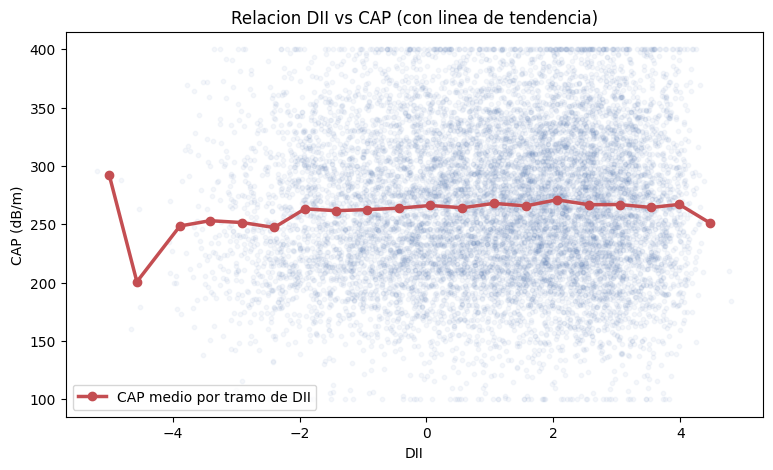

In [ ]:
import matplotlib.pyplot as plt

# Se visualiza la relacion DII vs CAP con una curva suavizada, para ver si hay
# un patron no lineal que la correlacion de Pearson (lineal) no captura.
datos = df_c[['DII', 'LUXCAPM']].dropna()

fig, ax = plt.subplots(figsize=(9, 5))

# Nube de puntos (con transparencia por el volumen de datos)
ax.scatter(datos['DII'], datos['LUXCAPM'], alpha=0.05, color='#4C72B0', s=10)

# Se agrupa el DII en tramos y se calcula el CAP medio de cada tramo (linea de tendencia real)
datos['DII_bin'] = pd.cut(datos['DII'], bins=20)
tendencia = datos.groupby('DII_bin', observed=True).agg(
    dii_medio=('DII', 'mean'), cap_medio=('LUXCAPM', 'mean'))
ax.plot(tendencia['dii_medio'], tendencia['cap_medio'],
        color='#C44E52', linewidth=2.5, marker='o', label='CAP medio por tramo de DII')

ax.set_xlabel('DII')
ax.set_ylabel('CAP (dB/m)')
ax.set_title('Relacion DII vs CAP (con linea de tendencia)')
ax.legend()
plt.show()

In [ ]:
from scipy.stats import spearmanr, f_oneway, kruskal

datos = df_c[['DII', 'LUXCAPM', 'DII_cuartil']].dropna()

# 1. Correlacion de Spearman: capta relaciones monotonas (no solo lineales como Pearson)
rho, p_spear = spearmanr(datos['DII'], datos['LUXCAPM'])
print('--- Correlaciones DII vs CAP ---')
print(f'Pearson (lineal)   : 0.045')
print(f'Spearman (monotona): {rho:.3f}  (p={p_spear:.4f})')

# 2. ¿El CAP difiere entre cuartiles de DII? Se testea con ANOVA y Kruskal-Wallis
grupos = [g['LUXCAPM'].values for _, g in datos.groupby('DII_cuartil', observed=True)]
f_stat, p_anova = f_oneway(*grupos)
h_stat, p_kw = kruskal(*grupos)

print(f'\n--- Diferencia de CAP entre cuartiles de DII ---')
print(f'ANOVA          : p={p_anova:.4f}')
print(f'Kruskal-Wallis : p={p_kw:.4f}')
print(f'\n(p < 0.05 = hay diferencia significativa; p > 0.05 = no se distinguen)')

--- Correlaciones DII vs CAP ---
Pearson (lineal)   : 0.045
Spearman (monotona): 0.042  (p=0.0000)

--- Diferencia de CAP entre cuartiles de DII ---
ANOVA          : p=0.0001
Kruskal-Wallis : p=0.0000

(p < 0.05 = hay diferencia significativa; p > 0.05 = no se distinguen)


### Análisis univariado del DII: significativo pero débil

Evalué la relación DII-CAP desde tres ángulos. Las correlaciones son muy bajas tanto en su forma lineal (Pearson = 0,045) como monótona (Spearman = 0,042), y el gráfico de tendencia mostró una relación esencialmente plana. Los tests entre cuartiles de DII resultan estadísticamente significativos (ANOVA p=0,0001; Kruskal-Wallis p<0,0001), pero interpreto esta significación con cautela: con más de 10.000 observaciones, diferencias muy pequeñas alcanzan significación sin ser clínicamente relevantes. De hecho, la diferencia de CAP entre cuartiles extremos es de apenas ~7 dB/m sobre un rango de 100-400, y el índice explica menos del 0,2% de la varianza del CAP.

Mi conclusión, tratada con honestidad, es que el DII presenta una asociación univariada estadísticamente detectable pero clínicamente trivial. Esto no justifica descartarlo todavía: su aporte real debo evaluarlo en el modelo multivariado y con SHAP, donde podría contribuir en interacción o quedar confirmado como débil. La distinción entre significación estadística y relevancia clínica la mantengo como criterio interpretativo transversal a todo el análisis.

### Adiposidad central: el WHtR

Construyo el segundo predictor clave: el **WHtR (Waist-to-Height Ratio)**, la relación cintura/talla, definido como la circunferencia de cintura dividida por la altura. Es un indicador de adiposidad central, la fracción de grasa corporal metabólicamente más vinculada a la esteatosis.

Elegí el WHtR por encima del IMC de forma deliberada. El IMC no distingue la localización de la grasa ni la separa de la masa muscular, de modo que puede clasificar igual a personas con riesgos muy distintos. El WHtR, al basarse en la cintura, captura directamente la adiposidad abdominal, ofrece un umbral simple y universal (0,5) y funciona de forma más consistente entre edades y etnias. Además, encaja con mi enfoque no invasivo: se obtiene en cualquier consulta con una cinta métrica. Lo calculé a partir de las variables ya integradas (`BMXWAIST` y `BMXHT`) y verifiqué su coherencia clínica frente al target.

In [ ]:
# Se construye el WHtR (cintura/talla), indicador de adiposidad central.
# Ambas variables estan en cm, asi que el cociente es directo.
df_c['WHtR'] = df_c['BMXWAIST'] / df_c['BMXHT']

print('--- WHtR (cintura/talla) ---')
print(df_c['WHtR'].describe().round(3))
print(f'\nPor encima del umbral de riesgo (>0.5): {(df_c["WHtR"] > 0.5).mean()*100:.1f}%')
print(f'Faltantes: {df_c["WHtR"].isna().sum():,}')

# Verificacion de coherencia clinica: CAP promedio por cuartil de WHtR
df_c['WHtR_cuartil'] = pd.qcut(df_c['WHtR'], 4, labels=['Q1 (menos)', 'Q2', 'Q3', 'Q4 (mas)'])
print('\nCAP promedio por cuartil de WHtR:')
print(df_c.groupby('WHtR_cuartil', observed=True)['LUXCAPM'].agg(['mean', 'count']).round(1))

# Correlacion WHtR vs CAP (para comparar con el DII)
corr_whtr = df_c[['WHtR', 'LUXCAPM']].corr().iloc[0, 1]
print(f'\nCorrelacion WHtR vs CAP: {corr_whtr:.3f}  (DII fue 0.045)')

--- WHtR (cintura/talla) ---
count    12046.000
mean         0.606
std          0.102
min          0.366
25%          0.533
50%          0.597
75%          0.671
max          1.126
Name: WHtR, dtype: float64

Por encima del umbral de riesgo (>0.5): 81.9%
Faltantes: 473

CAP promedio por cuartil de WHtR:
               mean  count
WHtR_cuartil              
Q1 (menos)    213.9   3012
Q2            252.9   3011
Q3            279.6   3011
Q4 (mas)      311.3   3012

Correlacion WHtR vs CAP: 0.586  (DII fue 0.045)


### Resultado del WHtR: un predictor fuerte

El WHtR muestra una asociación con el CAP radicalmente más fuerte que el DII: la correlación es de 0,586 (frente a 0,045 del DII), y el CAP promedio asciende de forma monótona y marcada a través de los cuartiles de adiposidad (de 213,9 dB/m en el más bajo a 311,3 en el más alto, casi 100 dB/m de diferencia). La adiposidad central se perfila así como un predictor potente, en contraste con el potencial inflamatorio de la dieta.

El 81,9% de la cohorte supera el umbral de riesgo (WHtR > 0,5), coherente con la alta prevalencia, y la variable tiene pocos faltantes (473). Este contraste DII-WHtR anticipa uno de los hallazgos centrales del trabajo: en la predicción no invasiva de la grasa hepática, la composición corporal pesa considerablemente más que la calidad inflamatoria de la dieta. Lejos de debilitar el enfoque nutricional, este resultado lo reorienta, ya que el WHtR es un parámetro directamente modificable mediante intervención dietética y de estilo de vida.

### Presión de pulso

La presión de pulso (diferencia entre la sistólica y la diastólica) es un marcador de rigidez arterial que aumenta con el daño vascular asociado al síndrome metabólico. La calculé a partir de las lecturas oscilométricas ya integradas (`BPXOSY1`, `BPXODI1`).

In [ ]:
# Se calcula la presion de pulso (sistolica - diastolica), marcador de rigidez arterial
df_c['presion_pulso'] = df_c['BPXOSY1'] - df_c['BPXODI1']

print('--- Presion de pulso (mmHg) ---')
print(df_c['presion_pulso'].describe().round(1))
print(f'Faltantes: {df_c["presion_pulso"].isna().sum():,}')

# Verificacion de coherencia con el CAP
corr_pp = df_c[['presion_pulso', 'LUXCAPM']].corr().iloc[0, 1]
print(f'\nCorrelacion presion de pulso vs CAP: {corr_pp:.3f}')

--- Presion de pulso (mmHg) ---
count    11720.0
mean        48.8
std         15.4
min         12.0
25%         38.0
50%         46.0
75%         56.0
max        154.0
Name: presion_pulso, dtype: float64
Faltantes: 799

Correlacion presion de pulso vs CAP: 0.007


### Resultado de la presión de pulso

La presión de pulso muestra una correlación prácticamente nula con el CAP (0,007). Como marcador de rigidez arterial (una consecuencia relativamente tardía del daño vascular), su falta de asociación transversal con la esteatosis es plausible: la grasa hepática puede instaurarse antes de que la rigidez arterial se manifieste. La conservo como predictor candidato para evaluar su posible aporte en interacción dentro del modelo multivariado, aunque su señal univariada es inexistente.

### Sintomatología depresiva: PHQ-8

Incorporo la carga de síntomas depresivos mediante el **PHQ-8**, la suma de los ocho primeros ítems del PHQ-9 (omito el ítem 9, sobre ideación de autolesión, según la decisión ya documentada). La depresión y la esteatosis comparten vías inflamatorias y conductuales (peor alimentación, menor actividad), lo que justifica evaluarla como predictor. Cada ítem puntúa de 0 a 3; el score final va de 0 a 24, donde valores más altos indican mayor sintomatología.

In [ ]:
import numpy as np

# Se construye el score PHQ-8: suma de los 8 primeros items (se excluye DPQ090, el item 9).
items_phq8 = [f'DPQ0{i}0' for i in range(1, 9)]  # DPQ010 a DPQ080

# Se limpian los codigos especiales 7 (rechazo) y 9 (no sabe): no son valores de la escala 0-3
phq_limpio = df_c[items_phq8].copy()
phq_limpio = phq_limpio.mask(phq_limpio >= 7, np.nan)

# Se suma; si algun item falta, el score queda NaN (no se suma parcial para no subestimar)
df_c['PHQ8'] = phq_limpio.sum(axis=1, min_count=8)  # min_count=8 exige los 8 items

print('--- PHQ-8 (score de depresion, 0-24) ---')
print(df_c['PHQ8'].describe().round(2))
print(f'Faltantes: {df_c["PHQ8"].isna().sum():,}')
print(f'Con sintomas relevantes (PHQ8>=10): {(df_c["PHQ8"]>=10).mean()*100:.1f}%')

# Coherencia con el CAP
corr_phq = df_c[['PHQ8', 'LUXCAPM']].corr().iloc[0, 1]
print(f'\nCorrelacion PHQ8 vs CAP: {corr_phq:.3f}')

--- PHQ-8 (score de depresion, 0-24) ---
count    11324.00
mean         3.37
std          4.20
min          0.00
25%          0.00
50%          2.00
75%          5.00
max         24.00
Name: PHQ8, dtype: float64
Faltantes: 1,195
Con sintomas relevantes (PHQ8>=10): 8.7%

Correlacion PHQ8 vs CAP: 0.057


### Resultado del PHQ-8

El PHQ-8 presenta una correlación baja con el CAP (0,057), en línea con el DII. El 8,7% de la cohorte supera el umbral de sintomatología relevante (PHQ-8 ≥ 10), coherente con la prevalencia poblacional esperada, lo que respalda la validez del cálculo. Aunque depresión y esteatosis comparten vías inflamatorias, su asociación transversal directa resulta débil. Lo conservo como predictor candidato para el modelo multivariado.

In [ ]:
# Se verifica el nivel de actividad sobre la cohorte final (ya sin menores)
etiquetas = {0: 'Inactivo', 1: 'Activo', 2: 'Muy activo'}

print('--- Nivel de actividad fisica en la cohorte ---')
dist = df_c['nivel_actividad'].map(etiquetas).value_counts(dropna=False)
print(dist)
print(f'\nFaltantes: {df_c["nivel_actividad"].isna().sum():,}')

# Coherencia con el CAP: ¿mas actividad se asocia a menos grasa hepatica?
print('\nCAP promedio por nivel de actividad:')
print(df_c.groupby('nivel_actividad', observed=True)['LUXCAPM'].agg(['mean', 'count']).round(1))

# Correlacion (tratando el nivel como ordinal: 0<1<2)
corr_act = df_c[['nivel_actividad', 'LUXCAPM']].corr().iloc[0, 1]
print(f'\nCorrelacion nivel_actividad vs CAP: {corr_act:.3f}')

--- Nivel de actividad fisica en la cohorte ---
nivel_actividad
Activo        5114
Inactivo      4740
Muy activo    2660
NaN              5
Name: count, dtype: int64

Faltantes: 5

CAP promedio por nivel de actividad:
                  mean  count
nivel_actividad              
0.0              272.5   4740
1.0              262.8   5114
2.0              253.0   2660

Correlacion nivel_actividad vs CAP: -0.116


### Resultado de la actividad física

Evaluada sobre la cohorte de adultos, la variable de actividad física queda prácticamente sin faltantes (solo 5), lo que confirma que los abundantes vacíos de la base completa correspondían a menores ya excluidos, y valida mi decisión de posponer su evaluación hasta esta fase. La relación con el CAP es coherente y protectora: el CAP promedio desciende de 272,5 dB/m en los inactivos a 253,0 en los muy activos, con una correlación de −0,116. Aunque modesta, es de las asociaciones más claras entre los predictores no invasivos tras la adiposidad, y respalda el rol del ejercicio como factor protector.

Con esto completo el Nivel 1. El panorama univariado es nítido: la adiposidad central (WHtR, r=0,586) domina ampliamente, seguida a distancia por la actividad física, mientras que dieta (DII), depresión (PHQ-8) y presión de pulso muestran asociaciones triviales. Su aporte definitivo lo dirimiré en el modelo multivariado.

### Resistencia insulínica: índice TyG

Inicio el Nivel 2 con el **índice TyG (triglicéridos-glucosa)**, un marcador validado de resistencia a la insulina, el mecanismo fisiopatológico central que vincula el síndrome metabólico con la esteatosis. Se calcula como el logaritmo natural del producto de triglicéridos y glucosa dividido por dos, y es un proxy económico del HOMA-IR sin requerir medir insulina.

Conforme a la decisión que tomé al integrar los datos, uso los valores de triglicéridos y glucosa no obtenidos en ayunas (disponibles en `BIOPRO` para toda la muestra), en lugar de restringirme a la submuestra en ayunas. Esto genera un TyG aproximado que maximiza el tamaño muestral; la versión clásica en ayunas queda como análisis de robustez.

In [ ]:
import numpy as np

# Se calcula el indice TyG = ln[(trigliceridos * glucosa) / 2], marcador de resistencia insulinica.
# Se usan trigliceridos y glucosa no-ayunas (BIOPRO) para cubrir toda la muestra.
df_c['TyG'] = np.log((df_c['trigliceridos'] * df_c['glucosa']) / 2)

print('--- Indice TyG ---')
print(df_c['TyG'].describe().round(3))
print(f'Faltantes: {df_c["TyG"].isna().sum():,}')

# Coherencia con el CAP
df_c['TyG_cuartil'] = pd.qcut(df_c['TyG'], 4, labels=['Q1 (menos)', 'Q2', 'Q3', 'Q4 (mas)'])
print('\nCAP promedio por cuartil de TyG:')
print(df_c.groupby('TyG_cuartil', observed=True)['LUXCAPM'].agg(['mean', 'count']).round(1))

corr_tyg = df_c[['TyG', 'LUXCAPM']].corr().iloc[0, 1]
print(f'\nCorrelacion TyG vs CAP: {corr_tyg:.3f}')

--- Indice TyG ---
count    11527.000
mean         8.663
std          0.647
min          6.789
25%          8.209
50%          8.599
75%          9.036
max         12.577
Name: TyG, dtype: float64
Faltantes: 992

CAP promedio por cuartil de TyG:
              mean  count
TyG_cuartil              
Q1 (menos)   228.4   2882
Q2           255.1   2884
Q3           275.8   2879
Q4 (mas)     300.2   2882

Correlacion TyG vs CAP: 0.438


### Resultado del TyG

El índice TyG muestra una asociación fuerte con el CAP (correlación 0,438), la segunda más alta tras el WHtR. El CAP promedio asciende de forma monótona y marcada entre cuartiles de TyG (de 228,4 dB/m en el de menor resistencia insulínica a 300,2 en el mayor, más de 70 dB/m de diferencia), confirmando el rol central de la resistencia a la insulina en la esteatosis.

Este resultado es relevante para mi arquitectura de dos niveles: mientras el predictor más potente (WHtR) es no invasivo y pertenece al Nivel 1, el TyG (Nivel 2) aporta una señal fuerte por una vía fisiopatológica distinta, la metabólica. Cuánto complementa o solapa esta información de laboratorio a la del Nivel 1 lo cuantificaré en el modelado, siendo esa comparación una de mis preguntas centrales.

### Colesterol no-HDL

Cierro el Nivel 2 con el **colesterol no-HDL** (colesterol total menos HDL), que agrupa todas las fracciones aterogénicas del colesterol. Es un marcador de riesgo cardiometabólico más completo que el LDL aislado y, a diferencia de este, no requiere ayunas. Lo calculo directamente a partir de las variables lipídicas ya integradas.

In [ ]:
# Se calcula el colesterol no-HDL (total - HDL), marcador de riesgo aterogenico global
df_c['no_HDL'] = df_c['colesterol_total'] - df_c['HDL']

print('--- Colesterol no-HDL (mg/dL) ---')
print(df_c['no_HDL'].describe().round(1))
print(f'Faltantes: {df_c["no_HDL"].isna().sum():,}')

# Coherencia con el CAP
corr_nohdl = df_c[['no_HDL', 'LUXCAPM']].corr().iloc[0, 1]
print(f'\nCorrelacion no-HDL vs CAP: {corr_nohdl:.3f}')

--- Colesterol no-HDL (mg/dL) ---
count    11508.0
mean       134.2
std         40.7
min         26.0
25%        105.0
50%        130.0
75%        158.0
max        409.0
Name: no_HDL, dtype: float64
Faltantes: 1,011

Correlacion no-HDL vs CAP: 0.165


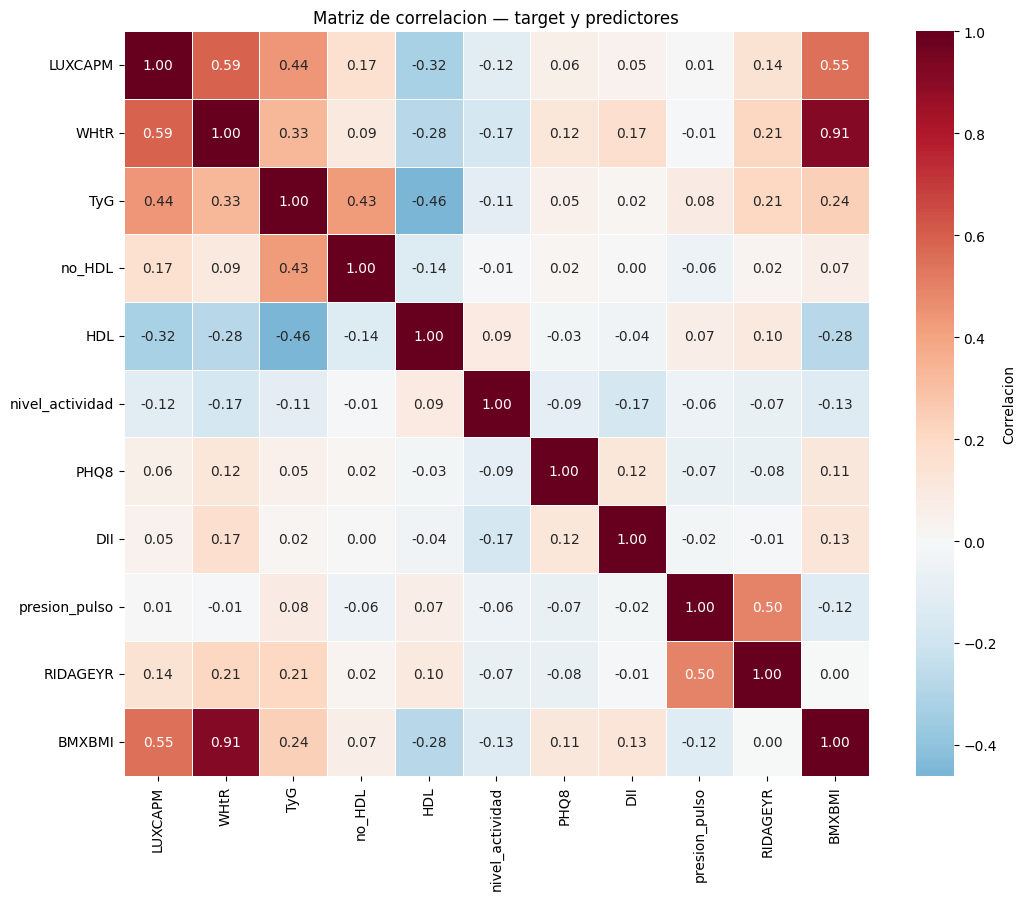

Correlacion de cada variable con el CAP (LUXCAPM):
WHtR               0.586
BMXBMI             0.545
TyG                0.438
HDL               -0.323
no_HDL             0.165
RIDAGEYR           0.139
nivel_actividad   -0.116
PHQ8               0.057
DII                0.045
presion_pulso      0.007
Name: LUXCAPM, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Se arma la matriz de correlacion con el target y todas las features construidas,
# incluyendo HDL (que hasta ahora solo se habia usado para calcular el no-HDL)
features_modelo = ['LUXCAPM', 'WHtR', 'TyG', 'no_HDL', 'HDL', 'nivel_actividad',
                   'PHQ8', 'DII', 'presion_pulso', 'RIDAGEYR', 'BMXBMI']

corr_matrix = df_c[features_modelo].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'label': 'Correlacion'}, ax=ax)
ax.set_title('Matriz de correlacion — target y predictores')
plt.tight_layout()
plt.show()

# Se listan las correlaciones con el target, ordenadas por fuerza
print('Correlacion de cada variable con el CAP (LUXCAPM):')
print(corr_matrix['LUXCAPM'].drop('LUXCAPM').sort_values(key=abs, ascending=False).round(3))

### Análisis de multicolinealidad

La matriz de correlación entre predictores revela una única redundancia crítica: el WHtR y el IMC (`BMXBMI`) están correlacionados al 0,91, esperable ya que ambos miden adiposidad. Mantener los dos introduciría multicolinealidad, que distorsiona los modelos lineales y reparte artificialmente la importancia entre variables equivalentes. Decidí conservar el WHtR y descartar el IMC, respaldado tanto por los datos (el WHtR correlaciona algo mejor con el CAP: 0,59 vs 0,55) como por el marco clínico (la adiposidad central es más relevante para la esteatosis que la masa corporal global).

El resto de las correlaciones entre predictores se mantienen en rangos sin riesgo de colinealidad. Destaco que el HDL y el no-HDL, pese a compartir el colesterol total en su origen, apenas se correlacionan (−0,14), por lo que conservo ambos como predictores independientes. Este control me deja un conjunto de predictores limpio para el modelado.

In [ ]:
# Se definen los predictores de cada nivel de la arquitectura.
# El IMC (BMXBMI) NO se incluye: es redundante con WHtR (r=0.91). Se conserva en el dataset
# para comparacion clinica y descripcion, pero no entra al modelo.

# Nivel 1: no invasivo (disponible en consulta nutricional, sin analitica)
predictores_n1 = ['WHtR', 'nivel_actividad', 'PHQ8', 'DII', 'presion_pulso',
                  'RIDAGEYR', 'RIAGENDR']

# Nivel 2: Nivel 1 + analitica de sangre
predictores_n2 = predictores_n1 + ['TyG', 'no_HDL', 'HDL', 'HbA1c']

# Variable objetivo
target = 'LUXCAPM'

print('--- Arquitectura de predictores ---')
print(f'Nivel 1 (no invasivo): {len(predictores_n1)} variables')
for v in predictores_n1:
    print(f'    {v}')
print(f'\nNivel 2 (+ analitica): {len(predictores_n2)} variables')
for v in predictores_n2:
    print(f'    {v}')

--- Arquitectura de predictores ---
Nivel 1 (no invasivo): 7 variables
    WHtR
    nivel_actividad
    PHQ8
    DII
    presion_pulso
    RIDAGEYR
    RIAGENDR

Nivel 2 (+ analitica): 11 variables
    WHtR
    nivel_actividad
    PHQ8
    DII
    presion_pulso
    RIDAGEYR
    RIAGENDR
    TyG
    no_HDL
    HDL
    HbA1c


In [ ]:
# Se calculan las correlaciones de cada predictor con el CAP, separadas por sexo,
# para detectar predictores que funcionen distinto en hombres y mujeres.
predictores = ['WHtR', 'TyG', 'HDL', 'no_HDL', 'HbA1c', 'nivel_actividad',
               'PHQ8', 'DII', 'presion_pulso', 'RIDAGEYR']

# RIAGENDR: 1=hombre, 2=mujer
hombres = df_c[df_c['RIAGENDR'] == 1]
mujeres = df_c[df_c['RIAGENDR'] == 2]

comparacion = pd.DataFrame({
    'Hombres': [hombres[[p, 'LUXCAPM']].corr().iloc[0, 1] for p in predictores],
    'Mujeres': [mujeres[[p, 'LUXCAPM']].corr().iloc[0, 1] for p in predictores],
}, index=predictores).round(3)

# Se agrega la diferencia para resaltar donde el sexo cambia mas la relacion
comparacion['Diferencia'] = (comparacion['Hombres'] - comparacion['Mujeres']).round(3)
comparacion = comparacion.sort_values('Diferencia', key=abs, ascending=False)

print('Correlacion con CAP, por sexo:')
print(comparacion)

Correlacion con CAP, por sexo:
                 Hombres  Mujeres  Diferencia
presion_pulso     -0.048    0.031      -0.079
HbA1c              0.240    0.307      -0.067
PHQ8               0.040    0.095      -0.055
TyG                0.405    0.459      -0.054
RIDAGEYR           0.117    0.160      -0.043
WHtR               0.632    0.596       0.036
no_HDL             0.152    0.180      -0.028
HDL               -0.300   -0.319       0.019
DII                0.058    0.073      -0.015
nivel_actividad   -0.128   -0.115      -0.013


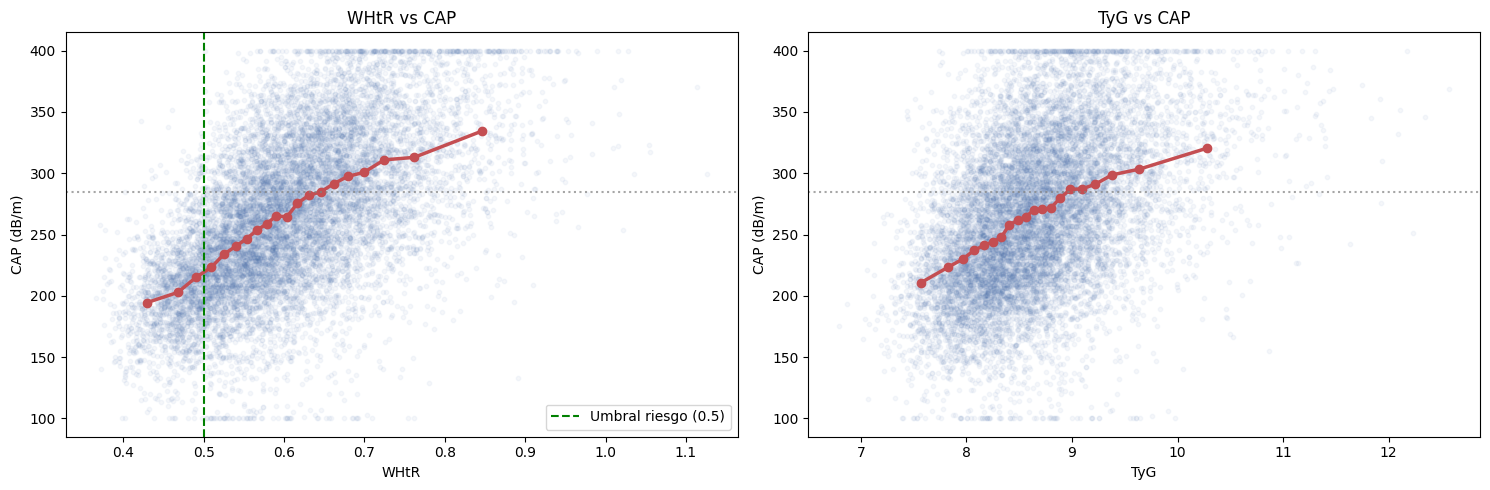

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Se grafica cada predictor fuerte vs CAP con linea de tendencia (CAP medio por tramo)
for ax, var, umbral, nombre in [(axes[0], 'WHtR', 0.5, 'WHtR'),
                                 (axes[1], 'TyG', None, 'TyG')]:
    datos = df_c[[var, 'LUXCAPM']].dropna()

    # Nube de puntos
    ax.scatter(datos[var], datos['LUXCAPM'], alpha=0.05, color='#4C72B0', s=10)

    # Linea de tendencia: CAP medio por tramo del predictor
    datos['bin'] = pd.qcut(datos[var], 20, duplicates='drop')
    tend = datos.groupby('bin', observed=True).agg(
        x=(var, 'mean'), cap=('LUXCAPM', 'mean'))
    ax.plot(tend['x'], tend['cap'], color='#C44E52', linewidth=2.5, marker='o')

    # Umbral clinico si lo tiene
    if umbral:
        ax.axvline(umbral, color='green', linestyle='--', label=f'Umbral riesgo ({umbral})')
        ax.legend()

    ax.axhline(285, color='gray', linestyle=':', alpha=0.7)  # corte esteatosis
    ax.set_xlabel(nombre)
    ax.set_ylabel('CAP (dB/m)')
    ax.set_title(f'{nombre} vs CAP')

plt.tight_layout()
plt.show()

### Forma de la relación de los predictores fuertes

Analicé la forma funcional de WHtR y TyG frente al CAP y encontré relaciones monótonas crecientes y predominantemente lineales. El WHtR presenta una leve aceleración en torno a su umbral clínico de 0,5, lo que valida empíricamente ese punto de corte: por encima de él, el CAP trepa más decididamente y alcanza el umbral de esteatosis (≈285 dB/m) alrededor de WHtR 0,65. El TyG exhibe una relación marcadamente lineal en todo su rango, sin saturación. La naturaleza mayormente lineal de ambas relaciones me anticipa un buen desempeño incluso del modelo lineal base, mientras que las curvaturas suaves (especialmente el codo del WHtR) justifican explorar modelos no lineales de árboles.

Correlacion WHtR vs CAP por grupo de edad:
  20-34   : 0.631  (n=2,599)
  35-49   : 0.587  (n=2,710)
  50-64   : 0.563  (n=3,496)
  65+     : 0.500  (n=3,088)


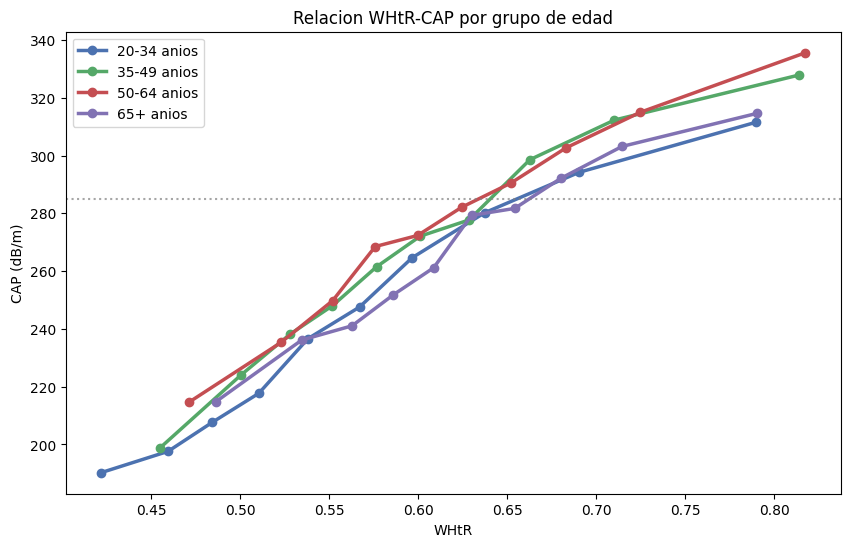

In [ ]:
import matplotlib.pyplot as plt

# Se divide la cohorte en grupos de edad para ver si la relacion WHtR-CAP cambia con la edad
df_c['grupo_edad'] = pd.cut(df_c['RIDAGEYR'], bins=[20, 35, 50, 65, 100],
                            labels=['20-34', '35-49', '50-64', '65+'])

fig, ax = plt.subplots(figsize=(10, 6))
colores = ['#4C72B0', '#55A868', '#C44E52', '#8172B3']

print('Correlacion WHtR vs CAP por grupo de edad:')
for grupo, color in zip(['20-34', '35-49', '50-64', '65+'], colores):
    sub = df_c[df_c['grupo_edad'] == grupo][['WHtR', 'LUXCAPM']].dropna()

    # Linea de tendencia por grupo
    sub_temp = sub.copy()
    sub_temp['bin'] = pd.qcut(sub_temp['WHtR'], 10, duplicates='drop')
    tend = sub_temp.groupby('bin', observed=True).agg(x=('WHtR','mean'), cap=('LUXCAPM','mean'))
    ax.plot(tend['x'], tend['cap'], color=color, linewidth=2.5, marker='o', label=f'{grupo} anios')

    # Correlacion del grupo
    corr = sub.corr().iloc[0, 1]
    print(f'  {grupo:<8}: {corr:.3f}  (n={len(sub):,})')

ax.axhline(285, color='gray', linestyle=':', alpha=0.7)
ax.set_xlabel('WHtR')
ax.set_ylabel('CAP (dB/m)')
ax.set_title('Relacion WHtR-CAP por grupo de edad')
ax.legend()

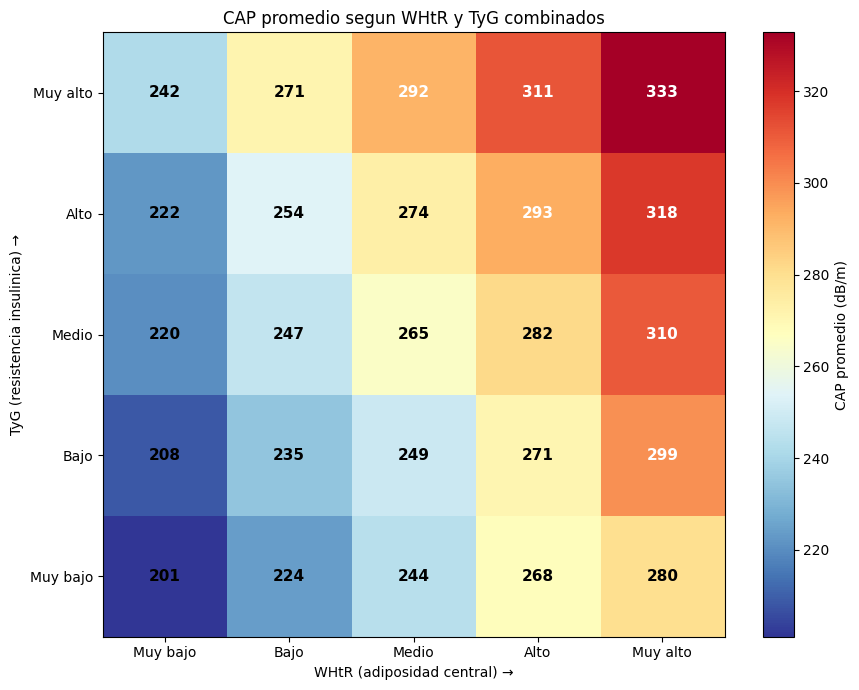

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Se cruzan los dos predictores fuertes en una grilla y se ve el CAP promedio de cada celda
datos = df_c[['WHtR', 'TyG', 'LUXCAPM']].dropna()

# Se divide cada predictor en 5 tramos (quintiles) para armar la grilla 5x5
datos['WHtR_q'] = pd.qcut(datos['WHtR'], 5, labels=['Muy bajo','Bajo','Medio','Alto','Muy alto'])
datos['TyG_q'] = pd.qcut(datos['TyG'], 5, labels=['Muy bajo','Bajo','Medio','Alto','Muy alto'])

# CAP promedio por celda de la grilla
grilla = datos.pivot_table(values='LUXCAPM', index='TyG_q', columns='WHtR_q',
                           aggfunc='mean', observed=True)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(grilla, cmap='RdYlBu_r', aspect='auto', origin='lower')

# Se anota el CAP en cada celda
for i in range(len(grilla.index)):
    for j in range(len(grilla.columns)):
        val = grilla.iloc[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.0f}', ha='center', va='center', fontsize=11,
                    color='white' if val > 285 else 'black', fontweight='bold')

ax.set_xticks(range(5)); ax.set_xticklabels(grilla.columns)
ax.set_yticks(range(5)); ax.set_yticklabels(grilla.index)
ax.set_xlabel('WHtR (adiposidad central) →')
ax.set_ylabel('TyG (resistencia insulinica) →')
ax.set_title('CAP promedio segun WHtR y TyG combinados')
plt.colorbar(im, label='CAP promedio (dB/m)')
plt.tight_layout()
plt.show()

## Exploración dirigida: análisis multivariado preliminar

Antes de pasar al modelado, hice una exploración adicional guiada por hipótesis clínicas concretas, no una búsqueda indiscriminada, para detectar patrones que las correlaciones univariadas no revelan. Examiné cuatro cuestiones.

**Consistencia entre sexos.** Las correlaciones de cada predictor con el CAP resultaron muy similares en hombres y mujeres (diferencias máximas de 0,08), con matices menores como una asociación algo mayor de la HbA1c en mujeres. Esta estabilidad me respalda para usar un modelo único con el sexo como covariable, en lugar de modelos separados.

**Forma funcional de los predictores fuertes.** WHtR y TyG mostraron relaciones monótonas crecientes y predominantemente lineales. El WHtR presenta una leve aceleración en torno a 0,5, que queda validada empíricamente; el TyG es lineal en todo su rango.

**Modulación por edad.** La fuerza predictiva del WHtR decrece de forma gradual con la edad (de 0,63 en 20-34 años a 0,50 en mayores de 65), lo que evidencia una interacción edad × WHtR: en población joven la adiposidad explica más directamente la esteatosis, mientras que en edades avanzadas intervienen otros factores. Esta interacción, no capturable por modelos lineales simples, refuerza mi interés en los modelos no lineales.

**Interacción WHtR × TyG.** El cruce de los dos predictores más potentes mostró que ambos aportan señal independiente y acumulativa: el CAP asciende tanto con la adiposidad como con la resistencia insulínica, desde 201 dB/m (ambos bajos) hasta 333 (ambos altos). De especial relevancia son los perfiles discordantes (WHtR bajo con TyG alto, CAP 242), que corresponden a esteatosis metabólica en individuos de apariencia magra, indetectables por un cribado basado solo en adiposidad. Este hallazgo es una prueba visual preliminar del valor incremental del Nivel 2.

En conjunto, esta exploración me confirma que los predictores están bien caracterizados, valida umbrales clínicos e identifica interacciones relevantes que cuantificaré en el modelado mediante SHAP.

In [ ]:
df_c.to_parquet('/content/drive/MyDrive/TFM/dataset_features.parquet')
print(f'Dataset guardado: {df_c.shape}')

Dataset guardado: (12519, 79)


In [ ]:
# Se cuantifican los faltantes en cada predictor de ambos niveles
todas_features = list(set(predictores_n2))
print('Faltantes por predictor:')
print(df_c[todas_features].isna().sum().sort_values(ascending=False))

print(f'\n--- Filas completas ---')
print(f'Total cohorte: {len(df_c):,}')
print(f'Completas para Nivel 1: {df_c[predictores_n1 + [target]].dropna().shape[0]:,}')
print(f'Completas para Nivel 2: {df_c[predictores_n2 + [target]].dropna().shape[0]:,}')

Faltantes por predictor:
DII                1670
PHQ8               1195
no_HDL             1011
TyG                 992
HDL                 922
presion_pulso       799
HbA1c               559
WHtR                473
nivel_actividad       5
RIDAGEYR              0
RIAGENDR              0
dtype: int64

--- Filas completas ---
Total cohorte: 12,519
Completas para Nivel 1: 9,685
Completas para Nivel 2: 8,994


In [ ]:
from sklearn.model_selection import train_test_split

# Se separa en train (80%) y test (20%) ANTES de imputar, para no contaminar la evaluacion.
# Se usa el Nivel 2 (superset de features) para tener todas las columnas disponibles.
X = df_c[predictores_n2].copy()
y = df_c[target].copy()

# Solo se exige que el target este presente (los predictores se imputan despues)
mask_target = y.notna()
X, y = X[mask_target], y[mask_target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f'Train: {X_train.shape[0]:,} filas')
print(f'Test : {X_test.shape[0]:,} filas')
print(f'Target sin faltantes: {y.notna().all()}')

Train: 10,015 filas
Test : 2,504 filas
Target sin faltantes: True


In [ ]:
# Se calcula la mediana del TRAIN para cada variable (ese sera el valor imputado en sus NaN).
# Solo se calcula, no se aplica aun: primero inspeccionamos.
valores_imputacion = X_train.median()

# Se arma una tabla transparente: que valor se imputa y cuantos NaN afecta en train y test
tabla = pd.DataFrame({
    'valor_a_imputar': valores_imputacion.round(2),
    'NaN_train': X_train.isna().sum(),
    'NaN_test': X_test.isna().sum(),
})
tabla['%_train_imputado'] = (tabla['NaN_train'] / len(X_train) * 100).round(1)
tabla = tabla.sort_values('NaN_train', ascending=False)

print('QUE SE VA A IMPUTAR EN CADA VARIABLE:')
print(tabla)

QUE SE VA A IMPUTAR EN CADA VARIABLE:
                 valor_a_imputar  NaN_train  NaN_test  %_train_imputado
DII                         1.28       1340       330              13.4
PHQ8                        2.00        979       216               9.8
no_HDL                    130.00        813       198               8.1
TyG                         8.60        803       189               8.0
HDL                        51.00        746       176               7.4
presion_pulso              46.00        650       149               6.5
HbA1c                       5.60        446       113               4.5
WHtR                        0.60        382        91               3.8
nivel_actividad             1.00          2         3               0.0
RIAGENDR                    2.00          0         0               0.0
RIDAGEYR                   54.00          0         0               0.0


### Imputación de valores faltantes

Los predictores presentan faltantes moderados (entre 4% y 13% según la variable, el mayor en el DII). Para no perder muestra ni sesgar la comparación entre niveles (que requiere la misma población), decidí imputar en lugar de eliminar filas.

Elegí el **KNN imputer** (k=5) frente a la imputación simple por mediana. La mediana asigna el mismo valor a todos los faltantes, ignorando el perfil individual; el KNN, en cambio, estima cada valor a partir de los individuos más similares en el resto de las variables, produciendo imputaciones clínicamente más coherentes (por ejemplo, un TyG faltante se estima con el de personas de adiposidad, edad y perfil lipídico semejantes). Es un método validado y de uso extendido en investigación biomédica.

Metodológicamente, ajusto el imputador únicamente sobre el conjunto de entrenamiento y lo aplico sin reajuste al de test, evitando toda fuga de información. La comparación con imputación múltiple (MICE) queda como análisis de sensibilidad futuro, aunque su impacto esperado es menor dado que los predictores más influyentes tienen pocos faltantes.

In [ ]:
from sklearn.impute import KNNImputer

# Se ajusta el KNN imputer SOLO sobre el train (aprende los vecinos del train).
# k=5: cada NaN se estima con el promedio de los 5 individuos mas parecidos.
imputer = KNNImputer(n_neighbors=5)

# Se ajusta en train y se transforma train y test por separado (sin fuga de informacion)
X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_imp = pd.DataFrame(
    imputer.transform(X_test), columns=X_test.columns, index=X_test.index)

# Se verifica que no queden faltantes
print('Faltantes tras imputar:')
print(f'  Train: {X_train_imp.isna().sum().sum()}')
print(f'  Test : {X_test_imp.isna().sum().sum()}')
print(f'\nShapes -> Train: {X_train_imp.shape} | Test: {X_test_imp.shape}')

Faltantes tras imputar:
  Train: 0
  Test : 0

Shapes -> Train: (10015, 11) | Test: (2504, 11)


In [ ]:
# Se compara, en las filas que estaban faltantes, que valor puso KNN vs lo que habria
# puesto la mediana simple. Se ve que KNN asigna valores personalizados, no todos iguales.
var = 'TyG'  # variable con faltantes y clinicamente relevante
mediana_train = X_train[var].median()

# Filas del train que tenian NaN en esa variable
filas_nan = X_train[X_train[var].isna()].index
valores_knn = X_train_imp.loc[filas_nan, var]

print(f'--- Imputacion de {var} (en las {len(filas_nan)} filas que estaban vacias) ---')
print(f'Mediana simple habria puesto SIEMPRE: {mediana_train:.2f}')
print(f'\nKNN, en cambio, asigno valores variados:')
print(valores_knn.describe().round(2))
print(f'\nValores distintos que asigno KNN: {valores_knn.nunique()} (la mediana pondria 1 solo)')

--- Imputacion de TyG (en las 803 filas que estaban vacias) ---
Mediana simple habria puesto SIEMPRE: 8.60

KNN, en cambio, asigno valores variados:
count    803.00
mean       8.70
std        0.38
min        7.80
25%        8.45
50%        8.70
75%        8.92
max       10.34
Name: TyG, dtype: float64

Valores distintos que asigno KNN: 797 (la mediana pondria 1 solo)


In [ ]:
# Se toman algunas personas a las que se les imputo el TyG y se muestran sus otras
# variables, para juzgar si el valor imputado es clinicamente coherente con su perfil.
var = 'TyG'
filas_nan = X_train[X_train[var].isna()].index

# Se arma una tabla con el TyG imputado + variables de contexto que SI tenian
contexto = ['WHtR', 'HDL', 'HbA1c', 'no_HDL', 'RIDAGEYR']
inspeccion = X_train_imp.loc[filas_nan, [var] + contexto].copy()
inspeccion = inspeccion.rename(columns={var: 'TyG_imputado'})

# Se ordena por el TyG imputado para ver los extremos (los mas altos y mas bajos)
inspeccion = inspeccion.sort_values('TyG_imputado')

print('=== 5 personas con el TyG imputado MAS BAJO ===')
print(inspeccion.head().round(2).to_string())
print('\n=== 5 personas con el TyG imputado MAS ALTO ===')
print(inspeccion.tail().round(2).to_string())

=== 5 personas con el TyG imputado MAS BAJO ===
       TyG_imputado  WHtR   HDL  HbA1c  no_HDL  RIDAGEYR
12493          7.80  0.72  57.4   5.20    82.0      25.0
4079           7.80  0.52  63.0   4.50    85.4      25.0
5570           7.81  0.59  53.2   5.34   136.4      30.0
7947           7.82  0.59  81.0   5.40   109.6      27.0
1966           7.85  0.46  78.0   5.00   110.4      28.0

=== 5 personas con el TyG imputado MAS ALTO ===
       TyG_imputado  WHtR   HDL  HbA1c  no_HDL  RIDAGEYR
2221           9.77  0.57  39.0    5.8   172.8      64.0
10898          9.97  0.79  40.4    8.1   161.4      51.0
4602          10.08  0.59  52.4   10.1   166.0      50.0
314           10.10  0.71  51.2    8.4   181.8      50.0
5790          10.34  0.52  40.6   12.2   169.2      45.0


In [ ]:
# Se inspecciona la coherencia de la imputacion del HDL (protector: alto=sano, bajo=malo)
var = 'HDL'
filas_nan = X_train[X_train[var].isna()].index

contexto = ['WHtR', 'TyG', 'HbA1c', 'no_HDL', 'RIDAGEYR']
inspeccion = X_train_imp.loc[filas_nan, [var] + contexto].copy()
inspeccion = inspeccion.rename(columns={var: 'HDL_imputado'})
inspeccion = inspeccion.sort_values('HDL_imputado')

print('=== 5 personas con el HDL imputado MAS BAJO (perfil malo esperado) ===')
print(inspeccion.head().round(2).to_string())
print('\n=== 5 personas con el HDL imputado MAS ALTO (perfil sano esperado) ===')
print(inspeccion.tail().round(2).to_string())

=== 5 personas con el HDL imputado MAS BAJO (perfil malo esperado) ===
       HDL_imputado  WHtR   TyG  HbA1c  no_HDL  RIDAGEYR
6001           33.0  0.68  9.74   7.04   151.0      43.0
10758          36.4  0.64  9.41   6.10   107.4      69.0
8466           36.4  0.60  9.15   5.24   166.6      29.0
2009           38.6  0.58  8.63   5.46   144.2      36.0
532            38.6  0.81  9.00   5.96   151.0      34.0

=== 5 personas con el HDL imputado MAS ALTO (perfil sano esperado) ===
      HDL_imputado  WHtR   TyG  HbA1c  no_HDL  RIDAGEYR
5837          75.0  0.61  9.07   6.40   147.2      55.0
9600          75.6  0.55  8.22   5.80   108.0      80.0
8059          76.4  0.60  8.73   5.80   112.2      56.0
8328          78.6  0.69  8.57   6.90   126.8      77.0
3045          83.2  0.56  8.13   5.78   135.0      68.0


## Imputación de valores faltantes — orden y validación

Profundizo en el procedimiento de imputación, que cuidé especialmente por su impacto en la validez del modelo.

**Orden metodológico.** Antes de imputar, separé los datos en entrenamiento (80%, 10.015 casos) y prueba (20%, 2.504 casos). Este orden es esencial: el imputador se ajusta únicamente sobre el entrenamiento y se aplica sin reajuste al de prueba, de modo que ninguna información del test influye en la imputación. Invertir este orden contaminaría la evaluación y produciría métricas optimistas y engañosas.

**Validación clínica.** No apliqué la imputación a ciegas: verifiqué su coherencia inspeccionando los perfiles de los casos imputados en las dos variables de laboratorio más afectadas. En el TyG, los valores imputados más altos recayeron en individuos con HbA1c elevada, HDL bajo y colesterol alto (perfil de síndrome metabólico), y los más bajos en personas jóvenes y metabólicamente sanas. En el HDL, la relación se reprodujo de forma inversa y coherente con su carácter protector. El KNN respetó además la independencia real entre HDL y no-HDL, sin forzar relaciones inexistentes. Esta validación caso a caso me confirma que los datos imputados son clínicamente plausibles, algo inalcanzable con una imputación por mediana.

## Fase 4 — Modelado

### Modelo base: regresión lineal

Inicio el modelado con una regresión lineal, que actúa como línea de base. Su desempeño establece el mínimo que los modelos más complejos deberán superar para justificar su mayor sofisticación. Entreno el baseline por separado para cada nivel de mi arquitectura (Nivel 1 no invasivo y Nivel 2 con analítica) para obtener una primera cuantificación del valor incremental de la información de laboratorio. Evalúo con tres métricas: RMSE y MAE (error de predicción en dB/m, cuanto menor mejor) y R² (varianza explicada, cuanto mayor mejor).

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluar_modelo(modelo, X_tr, y_tr, X_te, y_te, nombre):
    # Se entrena y se evalua en el test (datos nunca vistos)
    modelo.fit(X_tr, y_tr)
    pred = modelo.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    mae = mean_absolute_error(y_te, pred)
    r2 = r2_score(y_te, pred)
    print(f'{nombre:<25} | RMSE: {rmse:6.1f} | MAE: {mae:6.1f} | R2: {r2:.3f}')
    return {'nombre': nombre, 'rmse': rmse, 'mae': mae, 'r2': r2}

# Se separan las columnas de cada nivel (del set ya imputado)
X_train_n1 = X_train_imp[predictores_n1]
X_test_n1  = X_test_imp[predictores_n1]
X_train_n2 = X_train_imp[predictores_n2]
X_test_n2  = X_test_imp[predictores_n2]

print('--- Regresion Lineal (baseline) ---')
lin_n1 = evaluar_modelo(LinearRegression(), X_train_n1, y_train, X_test_n1, y_test, 'Lineal - Nivel 1')
lin_n2 = evaluar_modelo(LinearRegression(), X_train_n2, y_train, X_test_n2, y_test, 'Lineal - Nivel 2')

--- Regresion Lineal (baseline) ---
Lineal - Nivel 1          | RMSE:   48.6 | MAE:   38.1 | R2: 0.376
Lineal - Nivel 2          | RMSE:   47.0 | MAE:   36.8 | R2: 0.417


### Resultados del modelo base

La regresión lineal me da los primeros resultados del proyecto, y son reveladores. El Nivel 1 (no invasivo) alcanza un R² de 0,376 con un RMSE de 48,6 dB/m, mientras que el Nivel 2 (con analítica) mejora hasta un R² de 0,417 y un RMSE de 47,0 dB/m.

Tres observaciones son relevantes. Primera, ambos valores se sitúan en el rango de R² que anticipé (0,4-0,5), lo que confirma que mi expectativa sobre el techo de rendimiento (limitado por el ruido de la elastografía) estaba bien calibrada. Segunda, el Nivel 2 supera al Nivel 1, validando que la información de laboratorio aporta capacidad predictiva. Tercera, y más relevante para mis objetivos, ese aporte es modesto (+0,041 en R²): el modelo puramente no invasivo ya captura la mayor parte de la señal, y la analítica la refina en lugar de transformarla. Este hallazgo respalda la viabilidad de un cribado no invasivo. El error de ~48 dB/m sobre un rango de 100-400 confirma, además, la naturaleza orientativa (de cribado, no diagnóstica) de la herramienta.

### Modelos no lineales

Frente al baseline lineal, entrené tres modelos basados en árboles: Random Forest, XGBoost y LightGBM. A diferencia de la regresión lineal, estos capturan automáticamente relaciones no lineales e interacciones entre variables (como la interacción edad × WHtR o la aceleración del WHtR en torno a su umbral, que detecté en la exploración), por lo que esperaba que mejoraran el rendimiento. Entreno cada modelo para ambos niveles, manteniendo el mismo conjunto de test para una comparación justa. Por ahora los uso con parámetros por defecto; su optimización la abordo después.

In [ ]:
!pip install xgboost lightgbm -q

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Se definen los tres modelos de arboles (parametros por defecto por ahora)
modelos = {
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'XGBoost':       XGBRegressor(random_state=42, verbosity=0),
    'LightGBM':      LGBMRegressor(random_state=42, verbose=-1),
}

resultados = [lin_n1, lin_n2]  # se arrastran los del baseline para comparar

print('--- Modelos no lineales ---')
for nombre, modelo in modelos.items():
    # Nivel 1
    from sklearn.base import clone
    r1 = evaluar_modelo(clone(modelo), X_train_n1, y_train, X_test_n1, y_test, f'{nombre} - N1')
    r2 = evaluar_modelo(clone(modelo), X_train_n2, y_train, X_test_n2, y_test, f'{nombre} - N2')
    resultados.extend([r1, r2])

print('\n--- Tabla comparativa (ordenada por R2) ---')
tabla_res = pd.DataFrame(resultados).sort_values('r2', ascending=False)
print(tabla_res.to_string(index=False))

--- Modelos no lineales ---
Random Forest - N1        | RMSE:   49.1 | MAE:   38.2 | R2: 0.364
Random Forest - N2        | RMSE:   47.4 | MAE:   37.1 | R2: 0.405
XGBoost - N1              | RMSE:   50.2 | MAE:   39.3 | R2: 0.334
XGBoost - N2              | RMSE:   49.2 | MAE:   38.3 | R2: 0.360
LightGBM - N1             | RMSE:   47.9 | MAE:   37.5 | R2: 0.394
LightGBM - N2             | RMSE:   46.9 | MAE:   36.6 | R2: 0.420

--- Tabla comparativa (ordenada por R2) ---
            nombre      rmse       mae       r2
     LightGBM - N2 46.863852 36.567268 0.419580
  Lineal - Nivel 2 46.953227 36.770245 0.417364
Random Forest - N2 47.434075 37.064904 0.405370
     LightGBM - N1 47.887078 37.532460 0.393958
  Lineal - Nivel 1 48.580196 38.106062 0.376287
Random Forest - N1 49.060303 38.246175 0.363898
      XGBoost - N2 49.226160 38.270485 0.359590
      XGBoost - N1 50.200400 39.342542 0.333990


### Comparación de modelos

Contra lo que esperaba, los modelos no lineales no superaron al baseline lineal. El mejor resultado (LightGBM Nivel 2, R²=0,420) apenas supera a la regresión lineal de Nivel 2 (0,417), y varios modelos de árboles rinden por debajo del lineal. La explicación es coherente con mi exploración previa: las relaciones dominantes (WHtR, TyG) son esencialmente lineales, y las curvaturas e interacciones que detecté eran suaves, por lo que un modelo lineal las captura tan eficazmente como uno complejo.

Este resultado, lejos de ser negativo, me aporta tres conclusiones sólidas. Primera, la convergencia de cinco modelos distintos en torno a un R² de 0,36-0,42 confirma que ese es el techo real del problema, no un artefacto de un algoritmo concreto. Segunda, por el principio de parsimonia, la equivalencia de rendimiento favorece al modelo más simple e interpretable. Tercera, el patrón de mi arquitectura de dos niveles se mantiene en todos los modelos: el Nivel 2 supera consistentemente al Nivel 1 por un margen modesto. A continuación optimizo los hiperparámetros para confirmar si el margen se mantiene.

In [ ]:
import joblib

# Se guardan los conjuntos ya procesados (train/test imputados) y los resultados obtenidos.
# joblib es el estandar para guardar objetos de sklearn/ML (mejor que parquet para esto).
avances = {
    'X_train_imp': X_train_imp,
    'X_test_imp': X_test_imp,
    'y_train': y_train,
    'y_test': y_test,
    'predictores_n1': predictores_n1,
    'predictores_n2': predictores_n2,
    'resultados_baseline': resultados,  # tabla comparativa de modelos
}

joblib.dump(avances, '/content/drive/MyDrive/TFM/avances_modelado.pkl')
print('Avances guardados: datos imputados, split y resultados de modelos.')

Avances guardados: datos imputados, split y resultados de modelos.


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMRegressor

# Se define el espacio de busqueda: rangos razonables para cada hiperparametro
espacio_lgbm = {
    'n_estimators': [200, 400, 600, 800],        # cantidad de arboles
    'learning_rate': [0.01, 0.03, 0.05, 0.1],    # cuanto aprende en cada paso
    'max_depth': [3, 5, 7, -1],                  # profundidad de cada arbol (-1 = sin limite)
    'num_leaves': [15, 31, 63],                  # complejidad de cada arbol
    'subsample': [0.7, 0.8, 1.0],                # % de filas por arbol (evita sobreajuste)
    'colsample_bytree': [0.7, 0.8, 1.0],         # % de columnas por arbol
}

# Se busca sobre 50 combinaciones al azar, con validacion cruzada de 5 pliegues,
# optimizando el R2. Solo usa el TRAIN (el test queda intacto).
busqueda_lgbm = RandomizedSearchCV(
    LGBMRegressor(random_state=42, verbose=-1),
    param_distributions=espacio_lgbm,
    n_iter=50, cv=5, scoring='r2',
    random_state=42, n_jobs=-1, verbose=1
)

busqueda_lgbm.fit(X_train_n2, y_train)

print(f'\nMejor R2 (en validacion cruzada del train): {busqueda_lgbm.best_score_:.3f}')
print(f'Mejores parametros:')
for k, v in busqueda_lgbm.best_params_.items():
    print(f'  {k}: {v}')

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Mejor R2 (en validacion cruzada del train): 0.428
Mejores parametros:
  subsample: 1.0
  num_leaves: 31
  n_estimators: 600
  max_depth: 3
  learning_rate: 0.01
  colsample_bytree: 0.7


In [ ]:
from lightgbm import LGBMRegressor, early_stopping
from sklearn.model_selection import train_test_split

# Se separa un pequeño conjunto de validacion DEL TRAIN para vigilar el early stopping
# (el test sigue intacto, no se toca)
X_tr, X_val, y_tr, y_val = train_test_split(X_train_n2, y_train, test_size=0.15, random_state=42)

# Se usan los mejores hiperparametros encontrados, pero se sube n_estimators alto:
# el early stopping cortara solo cuando deje de mejorar.
modelo_final = LGBMRegressor(
    n_estimators=5000,          # tope alto; early stopping cortara antes
    learning_rate=0.01,
    max_depth=3,
    num_leaves=31,
    subsample=1.0,
    colsample_bytree=0.7,
    random_state=42, verbose=-1
)

# Se entrena vigilando la validacion; para si no mejora en 50 rondas seguidas
modelo_final.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    callbacks=[early_stopping(stopping_rounds=50)]
)

print(f'\nArboles usados (elegidos por early stopping): {modelo_final.best_iteration_}')

# Se evalua en el TEST (intacto)
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
pred = modelo_final.predict(X_test_n2)
print(f'R2 en test: {r2_score(y_test, pred):.3f}')
print(f'RMSE en test: {np.sqrt(mean_squared_error(y_test, pred)):.1f}')

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[686]	valid_0's l2: 2134.15

Arboles usados (elegidos por early stopping): 686
R2 en test: 0.434
RMSE en test: 46.3


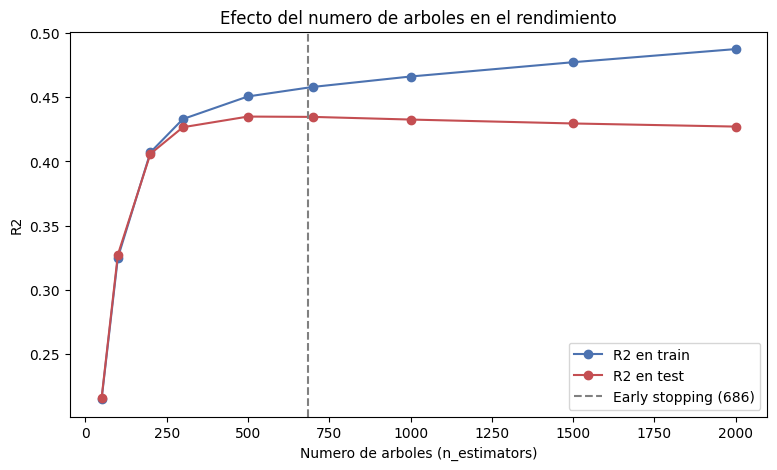

    50 arboles -> train: 0.215 | test: 0.216
   100 arboles -> train: 0.325 | test: 0.327
   200 arboles -> train: 0.407 | test: 0.406
   300 arboles -> train: 0.433 | test: 0.427
   500 arboles -> train: 0.451 | test: 0.435
   700 arboles -> train: 0.458 | test: 0.435
  1000 arboles -> train: 0.466 | test: 0.433
  1500 arboles -> train: 0.477 | test: 0.430
  2000 arboles -> train: 0.487 | test: 0.427


In [ ]:
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Se prueba el efecto del numero de arboles en el rendimiento (train vs test)
n_arboles = [50, 100, 200, 300, 500, 700, 1000, 1500, 2000]
r2_train, r2_test = [], []

for n in n_arboles:
    m = LGBMRegressor(n_estimators=n, learning_rate=0.01, max_depth=3, num_leaves=31,
                      subsample=1.0, colsample_bytree=0.7, random_state=42, verbose=-1)
    m.fit(X_train_n2, y_train)
    r2_train.append(r2_score(y_train, m.predict(X_train_n2)))
    r2_test.append(r2_score(y_test, m.predict(X_test_n2)))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(n_arboles, r2_train, marker='o', label='R2 en train', color='#4C72B0')
ax.plot(n_arboles, r2_test, marker='o', label='R2 en test', color='#C44E52')
ax.axvline(686, color='gray', linestyle='--', label='Early stopping (686)')
ax.set_xlabel('Numero de arboles (n_estimators)')
ax.set_ylabel('R2')
ax.set_title('Efecto del numero de arboles en el rendimiento')
ax.legend()
plt.show()

for n, tr, te in zip(n_arboles, r2_train, r2_test):
    print(f'  {n:>4} arboles -> train: {tr:.3f} | test: {te:.3f}')

### Análisis del sobreajuste: efecto del número de árboles

Para caracterizar el comportamiento del modelo y validar la selección del early stopping, analicé el efecto del número de árboles sobre el rendimiento en train y test. La curva revela el patrón clásico de sobreajuste. Hasta ~300 árboles, ambos conjuntos mejoran juntos (aprendizaje de patrones generalizables). El rendimiento en test alcanza su máximo en torno a 500-700 árboles (R²≈0,435), coincidiendo con el punto que seleccionó el early stopping (686). A partir de ahí, las curvas divergen: el R² en train sigue subiendo hasta 0,487 con 2.000 árboles, mientras que el de test decae hasta 0,427.

Esta divergencia es la manifestación empírica del sobreajuste: los árboles adicionales memorizan el ruido del entrenamiento sin aportar generalización. El análisis me confirma dos cosas: que el early stopping seleccionó correctamente el punto óptimo, y que el techo en datos no vistos es de ~0,435, siendo cualquier mejora aparente por encima un artefacto de sobreajuste sin validez real.

### Optimización de hiperparámetros

Optimicé el LightGBM (el modelo más prometedor) mediante RandomizedSearchCV (50 combinaciones, validación cruzada de 5 pliegues sobre el train, optimizando R²). La búsqueda seleccionó una configuración notablemente conservadora: tasa de aprendizaje baja (0,01) y árboles poco profundos (profundidad 3), coherente con un problema de techo predictivo acotado. Complementé el entrenamiento con early stopping, que determina automáticamente el número óptimo de árboles vigilando el error en un conjunto de validación interno; el procedimiento seleccionó 686 árboles.

El modelo resultante alcanza en test un R² de 0,434 y un RMSE de 46,3 dB/m, mi mejor rendimiento. La mejora sobre el baseline lineal (0,417) y sobre el modelo sin optimizar (0,420) es real pero modesta. Esta convergencia de todos los enfoques en torno a un R² de ~0,43 es evidencia sólida de haber alcanzado el techo predictivo real del problema, determinado por el ruido de la elastografía, más que una limitación de mi modelado.

### Clasificación derivada: evaluación como cribado

El uso clínico de mi herramienta no es predecir el valor exacto de CAP, sino cribar: distinguir a las personas con probable esteatosis (CAP ≥ 285) de las que probablemente no la tienen. Por eso, más allá del R², las métricas decisivas son las de una prueba de cribado. Derivo la clasificación binaria aplicando el umbral de 285 dB/m a las predicciones del modelo optimizado, y la evalúo con sensibilidad (proporción de casos reales detectados), especificidad (proporción de sanos correctamente descartados) y AUROC (capacidad global de discriminación). Comparo ambos niveles para cuantificar la utilidad del cribado no invasivo frente al que incorpora analítica.

In [ ]:
from lightgbm import LGBMRegressor, early_stopping
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.model_selection import train_test_split
import numpy as np

def modelo_optimizado(X_tr_full, y_tr_full):
    # Se entrena el LightGBM optimizado con early stopping (mejores params encontrados)
    X_tr, X_val, y_tr, y_val = train_test_split(X_tr_full, y_tr_full, test_size=0.15, random_state=42)
    m = LGBMRegressor(n_estimators=5000, learning_rate=0.01, max_depth=3, num_leaves=31,
                      subsample=1.0, colsample_bytree=0.7, random_state=42, verbose=-1)
    m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], callbacks=[early_stopping(50, verbose=False)])
    return m

def evaluar_cribado(X_tr, X_te, nombre, umbral=285):
    m = modelo_optimizado(X_tr, y_train)
    pred_cap = m.predict(X_te)
    real_bin = (y_test >= umbral).astype(int)
    pred_bin = (pred_cap >= umbral).astype(int)

    auroc = roc_auc_score(real_bin, pred_cap)
    tn, fp, fn, tp = confusion_matrix(real_bin, pred_bin).ravel()
    sens = tp / (tp + fn)
    espec = tn / (tn + fp)
    print(f'{nombre}')
    print(f'  AUROC: {auroc:.3f} | Sensibilidad: {sens:.3f} | Especificidad: {espec:.3f}')
    print(f'  VP={tp}  FN={fn}  FP={fp}  VN={tn}')
    return auroc

print('--- Cribado de esteatosis (corte CAP>=285) ---\n')
evaluar_cribado(X_train_n1, X_test_n1, 'Nivel 1 (no invasivo)')
print()
evaluar_cribado(X_train_n2, X_test_n2, 'Nivel 2 (+ analitica)')

--- Cribado de esteatosis (corte CAP>=285) ---

Nivel 1 (no invasivo)
  AUROC: 0.819 | Sensibilidad: 0.537 | Especificidad: 0.858
  VP=507  FN=437  FP=221  VN=1339

Nivel 2 (+ analitica)
  AUROC: 0.832 | Sensibilidad: 0.586 | Especificidad: 0.857
  VP=553  FN=391  FP=223  VN=1337


np.float64(0.8323853759235114)

### Resultados del cribado

Aplicado el umbral de 285 dB/m, el modelo alcanza un AUROC de 0,819 (Nivel 1) y 0,832 (Nivel 2), valores que indican buena capacidad discriminativa y confirman la utilidad de la herramienta como cribado. Notablemente, el Nivel 1 no invasivo ya alcanza un AUROC de 0,819. Sin embargo, la sensibilidad resulta baja (0,54 y 0,59), con un elevado número de falsos negativos: el modelo, al predecir de forma conservadora hacia valores centrales, subestima muchos casos reales. Dado que en un cribado es prioritario minimizar los casos no detectados, en el siguiente paso ajusto el umbral de decisión para mejorar la sensibilidad, aceptando un compromiso con la especificidad.

In [ ]:
from lightgbm import LGBMRegressor, early_stopping
from sklearn.model_selection import train_test_split
import numpy as np

# Se reentrena el modelo Nivel 2 optimizado
X_tr, X_val, y_tr, y_val = train_test_split(X_train_n2, y_train, test_size=0.15, random_state=42)
modelo = LGBMRegressor(n_estimators=5000, learning_rate=0.01, max_depth=3, num_leaves=31,
                       subsample=1.0, colsample_bytree=0.7, random_state=42, verbose=-1)
modelo.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], callbacks=[early_stopping(50, verbose=False)])

pred_cap = modelo.predict(X_test_n2)
real_bin = (y_test >= 285).astype(int)

# Se evalua el intercambio sensibilidad/especificidad para distintos umbrales de DECISION
print('Umbral | Sensib. | Especif. | Detectados | Falsos neg. | Falsas alarmas')
for umbral in [285, 275, 265, 255, 245, 235, 225]:
    pred_bin = (pred_cap >= umbral).astype(int)
    tp = ((pred_bin == 1) & (real_bin == 1)).sum()
    fn = ((pred_bin == 0) & (real_bin == 1)).sum()
    fp = ((pred_bin == 1) & (real_bin == 0)).sum()
    tn = ((pred_bin == 0) & (real_bin == 0)).sum()
    sens = tp / (tp + fn)
    espec = tn / (tn + fp)
    print(f'  {umbral}  |  {sens:.3f}  |  {espec:.3f}   |    {tp:4}    |    {fn:4}     |    {fp:4}')

Umbral | Sensib. | Especif. | Detectados | Falsos neg. | Falsas alarmas
  285  |  0.586  |  0.857   |     553    |     391     |     223
  275  |  0.696  |  0.781   |     657    |     287     |     341
  265  |  0.789  |  0.698   |     745    |     199     |     471
  255  |  0.873  |  0.602   |     824    |     120     |     621
  245  |  0.924  |  0.496   |     872    |      72     |     787
  235  |  0.965  |  0.394   |     911    |      33     |     945
  225  |  0.986  |  0.296   |     931    |      13     |    1098


### Calibración del umbral de decisión

El umbral de decisión sobre la predicción determina el equilibrio entre sensibilidad y especificidad, y su elección es una decisión clínica, no meramente técnica. Analicé el intercambio completo desplazando el punto de corte, sin que ello altere el AUROC (0,832): no cambio la capacidad del modelo, sino el punto de operación que elijo sobre la curva ROC.

El comportamiento es el esperado: al bajar el umbral, la sensibilidad aumenta a costa de la especificidad. En el extremo (umbral 225) se detecta el 98,6% de los casos, pero a costa de 1.098 falsas alarmas sobre 2.504 evaluados (cerca de la mitad de la población), lo que vacía de utilidad al cribado. Descartados los extremos, seleccioné dos puntos de operación defendibles:

- **Modo conservador (umbral 285):** sensibilidad 0,586 y especificidad 0,857. Coincide con el corte diagnóstico oficial, minimiza las falsas alarmas y maximiza el valor predictivo positivo. Adecuado cuando la prioridad es no sobrecargar el sistema de derivaciones.

- **Modo sensible (umbral 265):** sensibilidad 0,789 y especificidad 0,698. Detecta a casi cuatro de cada cinco casos reales, reduciendo los falsos negativos a la mitad. Más adecuado para un cribado poblacional de una enfermedad silenciosa como la MASLD.

Adopté el modo sensible (265) como configuración principal, por alinearse con el propósito de detección temprana, y mantengo el conservador (285) como alternativa documentada. Esta doble configuración refleja que el punto de operación debe adaptarse al contexto de uso.

In [ ]:
import joblib

# Se actualiza el guardado con el modelo final optimizado y los resultados de cribado
avances = {
    'X_train_imp': X_train_imp,
    'X_test_imp': X_test_imp,
    'y_train': y_train,
    'y_test': y_test,
    'predictores_n1': predictores_n1,
    'predictores_n2': predictores_n2,
    'modelo_final': modelo,          # LightGBM optimizado (Nivel 2)
    'umbral_principal': 265,
    'umbral_conservador': 285,
}

joblib.dump(avances, '/content/drive/MyDrive/TFM/avances_modelado.pkl')
print('Avances actualizados: modelo final + umbrales de cribado guardados.')

Avances actualizados: modelo final + umbrales de cribado guardados.


--- Importancia global de cada variable (SHAP) ---
       variable  importancia_shap
           WHtR         24.642632
            TyG          9.397274
       RIAGENDR          5.937126
          HbA1c          4.440657
            HDL          3.703730
       RIDAGEYR          2.760985
         no_HDL          1.305888
  presion_pulso          1.186244
            DII          0.874425
           PHQ8          0.120968
nivel_actividad          0.056077


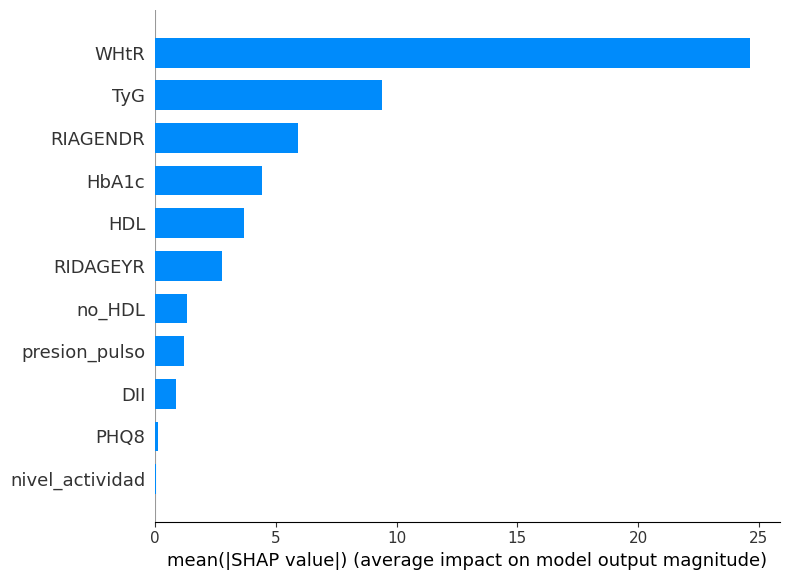

In [ ]:
import shap
import matplotlib.pyplot as plt

# Se calcula SHAP sobre el modelo final (LightGBM optimizado, Nivel 2)
explainer = shap.TreeExplainer(modelo)
shap_values = explainer.shap_values(X_test_n2)

# Importancia global: media del valor absoluto de SHAP por variable
print('--- Importancia global de cada variable (SHAP) ---')
importancia = pd.DataFrame({
    'variable': X_test_n2.columns,
    'importancia_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('importancia_shap', ascending=False)
print(importancia.to_string(index=False))

shap.summary_plot(shap_values, X_test_n2, plot_type='bar', show=False)
plt.tight_layout()
plt.show()

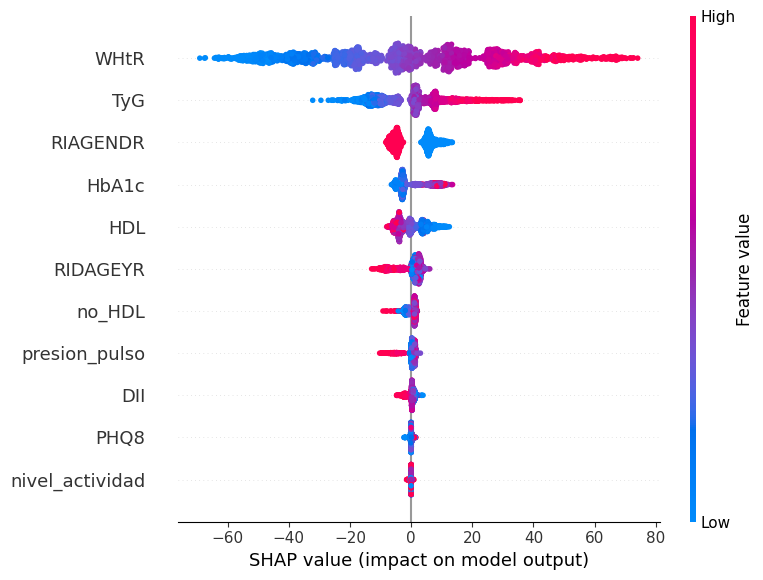

In [ ]:
import shap
import matplotlib.pyplot as plt

# Grafico beeswarm: cada punto es una persona. Posicion horizontal = cuanto y en que
# direccion esa variable movio SU prediccion. Color = valor de la variable (alto/bajo).
shap.summary_plot(shap_values, X_test_n2, show=False)
plt.tight_layout()
plt.show()

### Interpretación global y coherencia clínica

El análisis SHAP confirma y refina mi jerarquía de predictores. El WHtR domina ampliamente la importancia global (24,6), casi triplicando al segundo predictor (TyG, 9,4) y superando la suma del resto. Le siguen el sexo, la HbA1c y el HDL. En el extremo inferior, el DII (0,87), el PHQ-8 y la actividad física resultan prácticamente irrelevantes: SHAP, capaz de detectar aportes en interacción, confirma de forma definitiva que estas variables (en especial el DII) contribuyen muy poco, cerrando la cuestión que quedó abierta desde el análisis univariado.

Un hallazgo propio del análisis multivariado es la relevancia del sexo (tercer predictor), que apenas correlacionaba de forma directa con el CAP pero que SHAP revela influyente por su papel modulador, coherente con las diferencias de distribución de grasa entre sexos.

Fundamentalmente, el gráfico de dispersión SHAP valida la coherencia clínica del modelo: cada variable influye en la dirección fisiológicamente esperada. Los valores altos de WHtR, TyG y HbA1c empujan la predicción al alza, mientras que el HDL (correctamente interpretado como protector) la empuja a la baja. Esta coherencia me confirma que el modelo no opera como una caja negra arbitraria, sino que aprendió relaciones metabólicamente plausibles, lo que refuerza su validez como herramienta de orientación clínica.

Paciente #0
  CAP real: 209 dB/m | CAP predicho: 254 dB/m
  Sus valores:
    WHtR: 0.53
    nivel_actividad: 1.00
    PHQ8: 3.00
    DII: 0.59
    presion_pulso: 46.00
    RIDAGEYR: 65.00
    RIAGENDR: 2.00
    TyG: 8.99
    no_HDL: 152.00
    HDL: 57.00
    HbA1c: 6.18


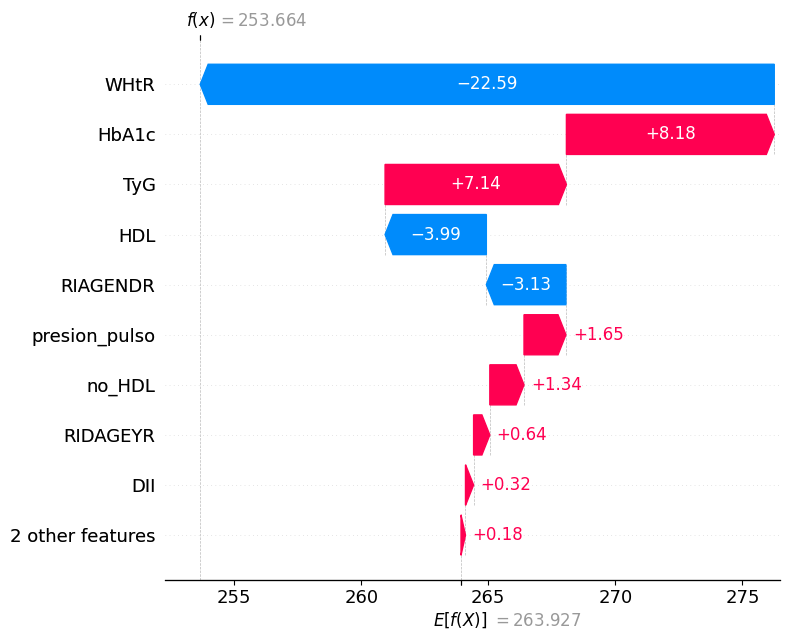

In [ ]:
import shap
import matplotlib.pyplot as plt

# Se elige un paciente del test para explicar su prediccion individual.
# Tomamos uno con CAP alto real, para ver que factores lo explican.
idx = 0  # primer paciente del test (podemos cambiarlo)

# Prediccion y valor real de ese paciente
pred_paciente = modelo.predict(X_test_n2.iloc[[idx]])[0]
real_paciente = y_test.iloc[idx]
print(f'Paciente #{idx}')
print(f'  CAP real: {real_paciente:.0f} dB/m | CAP predicho: {pred_paciente:.0f} dB/m')
print(f'  Sus valores:')
for var in X_test_n2.columns:
    print(f'    {var}: {X_test_n2.iloc[idx][var]:.2f}')

# Grafico waterfall: como cada variable empuja la prediccion desde la media hasta el valor final
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[idx],
    feature_names=list(X_test_n2.columns),
    show=False
)
plt.tight_layout()
plt.show()

Paciente #9
  CAP real: 329 dB/m | CAP predicho: 321 dB/m
  Sus valores:
    WHtR: 0.85
    nivel_actividad: 0.00
    PHQ8: 2.00
    DII: 2.59
    presion_pulso: 51.00
    RIDAGEYR: 53.00
    RIAGENDR: 2.00
    TyG: 8.79
    no_HDL: 140.00
    HDL: 51.00
    HbA1c: 5.40


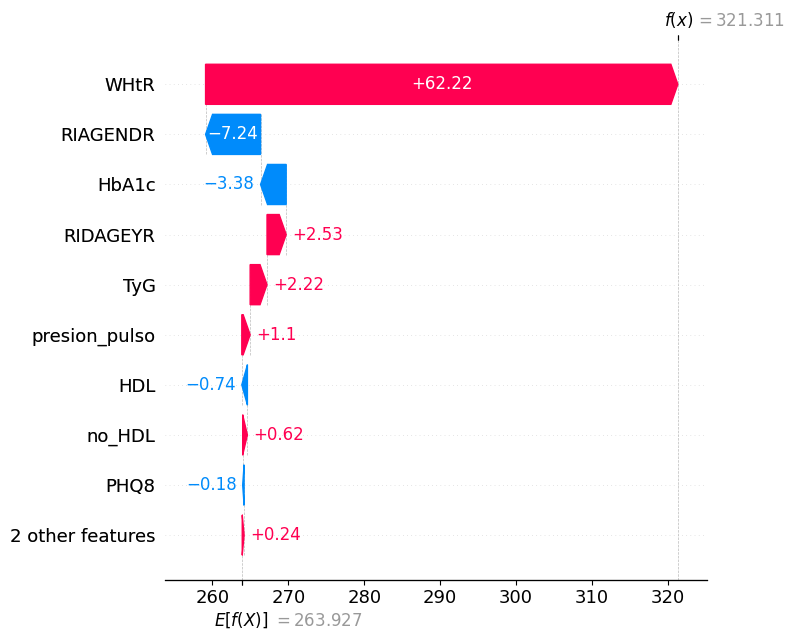

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# Se busca un paciente con CAP real alto (esteatosis clara) y bien predicho, para contrastar
real_bin = (y_test >= 285)
pred_cap = modelo.predict(X_test_n2)
# Entre los de CAP real alto, uno que el modelo tambien haya predicho alto
candidatos = np.where((y_test.values >= 320) & (pred_cap >= 300))[0]
idx = candidatos[0]

pred_paciente = pred_cap[idx]
real_paciente = y_test.iloc[idx]
print(f'Paciente #{idx}')
print(f'  CAP real: {real_paciente:.0f} dB/m | CAP predicho: {pred_paciente:.0f} dB/m')
print(f'  Sus valores:')
for var in X_test_n2.columns:
    print(f'    {var}: {X_test_n2.iloc[idx][var]:.2f}')

shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[idx],
    feature_names=list(X_test_n2.columns),
    show=False
)
plt.tight_layout()
plt.show()

### Interpretación individual: explicaciones por paciente

Más allá de la importancia global, SHAP me permite descomponer la predicción de cada paciente individual, lo que constituye la base de la utilidad de la herramienta en consulta. Lo ilustro con dos casos contrastantes.

En el primero (una mujer de 65 años con CAP real de 209 dB/m, sin esteatosis), el modelo predijo 254 dB/m. Su WHtR relativamente bajo (0,53) fue el principal factor protector (−22,6), mientras que su HbA1c elevada (6,18) y su TyG (8,99) empujaron la predicción al alza. Es un caso de perfil discordante (adiposidad baja pero marcadores metabólicos alterados) en el que el modelo sobrestimó el CAP en 45 dB/m, lo que ilustra los límites de la herramienta y refuerza su carácter orientativo.

En el segundo (una mujer de 53 años con CAP real de 329 dB/m, esteatosis clara), el modelo predijo 321, acertando con precisión. Aquí la historia es casi monotemática: su WHtR muy elevado (0,85) aportó +66,2 a la predicción, dominando por completo, mientras que sus marcadores metabólicos normales no añadieron riesgo.

El contraste es clínicamente revelador: la misma variable (WHtR) actúa como factor protector en un caso y como principal impulsor de riesgo en el otro, según su valor. Esto demuestra que mi herramienta no ofrece un puntaje opaco, sino que identifica el factor de riesgo dominante de cada individuo, la palanca sobre la que el nutricionista puede intervenir.

### Selección de variables: hacia un modelo parsimonioso

Dado que SHAP me reveló que varias variables aportan mínimamente, evalué si un modelo reducido mantiene el rendimiento del completo. Un modelo más simple, si rinde igual, es preferible: más interpretable, más fácil de usar en consulta (menos datos a recabar) y menos propenso al sobreajuste. Comparo el modelo completo con dos versiones reducidas, guiadas por la importancia SHAP.

In [ ]:
from lightgbm import LGBMRegressor, early_stopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, roc_auc_score
import numpy as np

def entrenar_y_evaluar(cols, nombre):
    X_tr_f, X_val, y_tr_f, y_val = train_test_split(
        X_train_imp[cols], y_train, test_size=0.15, random_state=42)
    m = LGBMRegressor(n_estimators=5000, learning_rate=0.01, max_depth=3, num_leaves=31,
                      subsample=1.0, colsample_bytree=0.7, random_state=42, verbose=-1)
    m.fit(X_tr_f, y_tr_f, eval_set=[(X_val, y_val)], callbacks=[early_stopping(50, verbose=False)])
    pred = m.predict(X_test_imp[cols])
    r2 = r2_score(y_test, pred)
    auroc = roc_auc_score((y_test >= 285).astype(int), pred)
    print(f'{nombre:<28} ({len(cols):2} vars) | R2: {r2:.3f} | AUROC: {auroc:.3f}')
    return r2, auroc

# Se definen los tres conjuntos, guiados por la importancia SHAP
completo = predictores_n2  # 11 variables
parsimonioso = ['WHtR', 'TyG', 'RIAGENDR', 'HbA1c', 'HDL', 'RIDAGEYR']  # las que pesan
minimo = ['WHtR', 'TyG', 'HbA1c']  # las 3 top

print('--- Comparacion de modelos por complejidad ---')
entrenar_y_evaluar(completo, 'Completo')
entrenar_y_evaluar(parsimonioso, 'Parsimonioso')
entrenar_y_evaluar(minimo, 'Minimo')

--- Comparacion de modelos por complejidad ---
Completo                     (11 vars) | R2: 0.434 | AUROC: 0.832
Parsimonioso                 ( 6 vars) | R2: 0.433 | AUROC: 0.832
Minimo                       ( 3 vars) | R2: 0.395 | AUROC: 0.821


(0.39472124969786493, np.float64(0.8206367476097349))

### Resultado: modelo parsimonioso

La comparación por complejidad me da un resultado concluyente: el modelo parsimonioso de 6 variables (WHtR, TyG, sexo, HbA1c, HDL y edad) iguala exactamente el rendimiento del completo de 11 (R² 0,433 vs 0,434; AUROC 0,832 en ambos). Esto confirma con evidencia que las cinco variables descartadas (DII, PHQ-8, actividad física, presión de pulso y no-HDL) no aportan capacidad predictiva, validando su eliminación. El modelo resultante es más simple, interpretable y aplicable, sin sacrificio de rendimiento.

Un modelo aún más reducido, de solo tres variables (WHtR, TyG, HbA1c), mantiene una capacidad de cribado notable (AUROC 0,821), aunque con una caída en la regresión (R² 0,395); el sexo, el HDL y la edad aportan ese tramo final.

Este resultado me obliga a una lectura honesta: los predictores que sobreviven a la simplificación son fundamentalmente de adiposidad (WHtR) y metabólicos (TyG, HbA1c, HDL), mientras que las variables dietéticas y conductuales autorreportadas (DII, actividad, PHQ-8) no contribuyen. En estos datos, la esteatosis se predice mejor por la composición corporal y el perfil metabólico que por la calidad autorreportada de la dieta y el estilo de vida.

In [ ]:
import joblib
from lightgbm import LGBMRegressor, early_stopping
from sklearn.model_selection import train_test_split

# Se reentrena y guarda el modelo parsimonioso final (6 variables)
parsimonioso = ['WHtR', 'TyG', 'RIAGENDR', 'HbA1c', 'HDL', 'RIDAGEYR']
X_tr_f, X_val, y_tr_f, y_val = train_test_split(
    X_train_imp[parsimonioso], y_train, test_size=0.15, random_state=42)
modelo_final = LGBMRegressor(n_estimators=5000, learning_rate=0.01, max_depth=3, num_leaves=31,
                             subsample=1.0, colsample_bytree=0.7, random_state=42, verbose=-1)
modelo_final.fit(X_tr_f, y_tr_f, eval_set=[(X_val, y_val)], callbacks=[early_stopping(50, verbose=False)])

avances = joblib.load('/content/drive/MyDrive/TFM/avances_modelado.pkl')
avances['modelo_parsimonioso'] = modelo_final
avances['predictores_parsimonioso'] = parsimonioso
joblib.dump(avances, '/content/drive/MyDrive/TFM/avances_modelado.pkl')
print('Modelo parsimonioso guardado.')

Modelo parsimonioso guardado.


In [ ]:
from lightgbm import LGBMRegressor, early_stopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, roc_auc_score
import numpy as np

def entrenar_y_evaluar(cols, nombre):
    X_tr_f, X_val, y_tr_f, y_val = train_test_split(
        X_train_imp[cols], y_train, test_size=0.15, random_state=42)
    m = LGBMRegressor(n_estimators=5000, learning_rate=0.01, max_depth=3, num_leaves=31,
                      subsample=1.0, colsample_bytree=0.7, random_state=42, verbose=-1)
    m.fit(X_tr_f, y_tr_f, eval_set=[(X_val, y_val)], callbacks=[early_stopping(50, verbose=False)])
    pred = m.predict(X_test_imp[cols])
    r2 = r2_score(y_test, pred)
    auroc = roc_auc_score((y_test >= 285).astype(int), pred)
    print(f'{nombre:<38} ({len(cols)} vars) | R2: {r2:.3f} | AUROC: {auroc:.3f}')
    return r2, auroc

print('--- Cuanto se pierde al simplificar ---\n')
entrenar_y_evaluar(['WHtR','RIDAGEYR','RIAGENDR'], 'Solo WHtR + demografia (no invasivo min.)')
entrenar_y_evaluar(['WHtR','RIDAGEYR','RIAGENDR','presion_pulso','nivel_actividad','DII','PHQ8'], 'Nivel 1 completo (no invasivo)')
entrenar_y_evaluar(['WHtR','TyG','RIAGENDR','HbA1c','HDL','RIDAGEYR'], 'Parsimonioso (+ sangre)')


--- Cuanto se pierde al simplificar ---

Solo WHtR + demografia (no invasivo min.) (3 vars) | R2: 0.394 | AUROC: 0.814
Nivel 1 completo (no invasivo)         (7 vars) | R2: 0.404 | AUROC: 0.819
Parsimonioso (+ sangre)                (6 vars) | R2: 0.433 | AUROC: 0.832


(0.43265324694109675, np.float64(0.8324526021295089))

In [ ]:
from lightgbm import LGBMRegressor, early_stopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, roc_auc_score
import numpy as np
import joblib

# Se definen los dos modelos finales de la herramienta
vars_simple = ['WHtR', 'RIDAGEYR', 'RIAGENDR']                       # entrada 1: sin analitica
vars_sangre = ['WHtR', 'RIDAGEYR', 'RIAGENDR', 'TyG', 'HbA1c', 'HDL']  # entrada 2: con analitica

def entrenar_final(cols):
    X_tr_f, X_val, y_tr_f, y_val = train_test_split(
        X_train_imp[cols], y_train, test_size=0.15, random_state=42)
    m = LGBMRegressor(n_estimators=5000, learning_rate=0.01, max_depth=3, num_leaves=31,
                      subsample=1.0, colsample_bytree=0.7, random_state=42, verbose=-1)
    m.fit(X_tr_f, y_tr_f, eval_set=[(X_val, y_val)], callbacks=[early_stopping(50, verbose=False)])
    return m

modelo_simple = entrenar_final(vars_simple)
modelo_sangre = entrenar_final(vars_sangre)

# Se verifican las metricas finales de cada uno
for m, cols, nombre in [(modelo_simple, vars_simple, 'SIMPLE (sin sangre)'),
                        (modelo_sangre, vars_sangre, 'COMPLETO (con sangre)')]:
    pred = m.predict(X_test_imp[cols])
    r2 = r2_score(y_test, pred)
    auroc = roc_auc_score((y_test >= 285).astype(int), pred)
    print(f'{nombre:<24} | R2: {r2:.3f} | AUROC: {auroc:.3f} | vars: {cols}')

# Se guardan ambos modelos como los definitivos
avances = joblib.load('/content/drive/MyDrive/TFM/avances_modelado.pkl')
avances['modelo_simple'] = modelo_simple
avances['vars_simple'] = vars_simple
avances['modelo_sangre'] = modelo_sangre
avances['vars_sangre'] = vars_sangre
joblib.dump(avances, '/content/drive/MyDrive/TFM/avances_modelado.pkl')
print('\nAmbos modelos finales guardados.')

SIMPLE (sin sangre)      | R2: 0.394 | AUROC: 0.814 | vars: ['WHtR', 'RIDAGEYR', 'RIAGENDR']
COMPLETO (con sangre)    | R2: 0.433 | AUROC: 0.832 | vars: ['WHtR', 'RIDAGEYR', 'RIAGENDR', 'TyG', 'HbA1c', 'HDL']

Ambos modelos finales guardados.


## Diseño final: herramienta de dos entradas

Los análisis de simplificación me condujeron a rediseñar la arquitectura original, guiado por la evidencia empírica y por el uso clínico real. La comparación de modelos por complejidad me dio dos conclusiones determinantes. Primera: las variables dietéticas y conductuales autorreportadas (DII, actividad física, PHQ-8) y algunas clínicas (presión de pulso, no-HDL) no aportan capacidad predictiva; un modelo con solo WHtR, edad y sexo alcanza un AUROC de 0,814, prácticamente idéntico al del Nivel 1 completo (0,819). Segunda: la información analítica (TyG, HbA1c, HDL) sí aporta una mejora modesta pero consistente, elevando el AUROC a 0,832.

En consecuencia, redefiní la herramienta en torno a dos entradas, según la información disponible en la consulta:

- **Entrada simple (no invasiva):** requiere únicamente circunferencia de cintura, talla, edad y sexo, datos obtenibles con una cinta métrica en cualquier consulta. Alcanza un AUROC de 0,814, suficiente para un cribado clínicamente útil.

- **Entrada con analítica:** incorpora tres marcadores de sangre (TyG, HbA1c, HDL) para los pacientes que acuden con análisis recientes, situación habitual en la práctica nutricional. Refina la estimación hasta un AUROC de 0,832.

Este diseño le da al nutricionista flexibilidad según el contexto, sin obligar a ningún estudio pero aprovechando la analítica cuando está disponible. Y reformula mi hallazgo central con honestidad: la predicción no invasiva de la esteatosis descansa fundamentalmente en la adiposidad central (WHtR), se refina modestamente con marcadores metabólicos, y no mejora con las variables dietéticas ni conductuales autorreportadas.

In [ ]:
import shap
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor, early_stopping
from sklearn.model_selection import train_test_split

# Se entrena un modelo SIN WHtR (ni IMC) para ver si el DII recupera importancia.
# Si la dieta estaba "tapada" por la adiposidad, sin ella deberia pesar mas.
vars_sin_adiposidad = ['DII', 'nivel_actividad', 'PHQ8', 'presion_pulso',
                       'RIDAGEYR', 'RIAGENDR', 'TyG', 'HbA1c', 'HDL', 'no_HDL']

X_tr_f, X_val, y_tr_f, y_val = train_test_split(
    X_train_imp[vars_sin_adiposidad], y_train, test_size=0.15, random_state=42)
modelo_sin_wh = LGBMRegressor(n_estimators=5000, learning_rate=0.01, max_depth=3, num_leaves=31,
                              subsample=1.0, colsample_bytree=0.7, random_state=42, verbose=-1)
modelo_sin_wh.fit(X_tr_f, y_tr_f, eval_set=[(X_val, y_val)], callbacks=[early_stopping(50, verbose=False)])

# Importancia SHAP sin la adiposidad presente
explainer_sw = shap.TreeExplainer(modelo_sin_wh)
shap_sw = explainer_sw.shap_values(X_test_imp[vars_sin_adiposidad])

imp_sw = pd.DataFrame({
    'variable': vars_sin_adiposidad,
    'importancia_SIN_WHtR': np.abs(shap_sw).mean(axis=0)
}).sort_values('importancia_SIN_WHtR', ascending=False)

print('--- Importancia SHAP SIN WHtR en el modelo ---')
print(imp_sw.to_string(index=False))

# Comparacion clave: el DII antes (con WHtR) vs ahora (sin WHtR)
print(f'\n--- El DII en foco ---')
print(f'Importancia del DII CON WHtR presente : 0.87 (era el puesto 9 de 11)')
dii_sin = imp_sw[imp_sw["variable"]=="DII"]["importancia_SIN_WHtR"].values[0]
print(f'Importancia del DII SIN WHtR presente : {dii_sin:.2f}')

--- Importancia SHAP SIN WHtR en el modelo ---
       variable  importancia_SIN_WHtR
            TyG             14.104753
          HbA1c              9.607019
            HDL              9.347308
       RIDAGEYR              4.125411
  presion_pulso              2.096022
         no_HDL              1.677303
           PHQ8              1.113554
nivel_actividad              1.103394
            DII              0.398140
       RIAGENDR              0.272063

--- El DII en foco ---
Importancia del DII CON WHtR presente : 0.87 (era el puesto 9 de 11)
Importancia del DII SIN WHtR presente : 0.40


### Por qué la dieta no predijo: descartando la mediación

Una explicación plausible para la irrelevancia del DII era la mediación por adiposidad: si la dieta influye en la esteatosis a través de la acumulación de grasa, su efecto quedaría "absorbido" por el WHtR, que lo mide directamente. Sin embargo, esa hipótesis predice que, al eliminar el WHtR del modelo, el DII debería recuperar parte de su importancia.

Puse a prueba esta predicción entrenando un modelo sin variables de adiposidad. El resultado la refuta: lejos de aumentar, la importancia del DII se mantuvo ínfima (SHAP de 0,40, penúltimo lugar). El espacio predictivo dejado por la adiposidad lo ocuparon enteramente los marcadores metabólicos (TyG 14,1, HbA1c 9,6 y HDL 9,3), no la dieta. Mi conclusión es que el efecto del DII no estaba enmascarado por la adiposidad: sencillamente no existe señal predictiva detectable en él.

Descartada la mediación, las explicaciones más plausibles son otras: (i) el ruido intrínseco del autorreporte dietético, construido a partir de dos recordatorios de 24 h que capturan imperfectamente la dieta habitual; (ii) la posibilidad de que el potencial inflamatorio de la dieta sea un mecanismo menos determinante de la esteatosis que el balance energético y la resistencia insulínica, coherente con el dominio de los marcadores metabólicos; y (iii) la naturaleza transversal de los datos, que no capta el efecto acumulado de la dieta a lo largo del tiempo. La jerarquía predictiva que emerge es nítida: adiposidad central, seguida del perfil metabólico, mientras que la calidad dietética autorreportada no contribuye.

In [ ]:
import pyreadstat

archivos = [
    '/content/drive/MyDrive/TFM/Nhanes 2017-2020/Questionaries/P_MCQ.xpt',
    '/content/drive/MyDrive/TFM/Nhanes 2021-2023/Questionary/MCQ_L.xpt',
]

for ruta in archivos:
    _, meta = pyreadstat.read_xport(ruta)
    print(f'\n=== {ruta.split("/")[-1]} ===')
    # Se listan TODAS las variables con su etiqueta, para no perder ninguna
    for col, lab in meta.column_names_to_labels.items():
        print(f'  {col}: {lab}')


=== P_MCQ.xpt ===
  SEQN: Respondent sequence number
  MCQ010: Ever been told you have asthma
  MCQ025: Age when first had asthma
  MCQ035: Still have asthma
  MCQ040: Had asthma attack in past year
  MCQ050: Emergency care visit for asthma/past yr
  AGQ030: Did SP have episode of hay fever/past yr
  MCQ053: Taking treatment for anemia/past 3 mos
  MCQ080: Doctor ever said you were overweight
  MCQ092: Ever receive blood transfusion
  MCD093: Year receive blood transfusion
  MCQ149: Menstrual periods started yet?
  MCQ151: Age in years at first menstrual period
  RHD018: Estimated age in months at menarche
  MCQ160A: Doctor ever said you had arthritis
  MCQ195: Which type of arthritis was it?
  MCQ160B: Ever told had congestive heart failure
  MCD180B: Age when told you had heart failure
  MCQ160C: Ever told you had coronary heart disease
  MCD180C: Age when told had coronary heart disease
  MCQ160D: Ever told you had angina/angina pectoris
  MCD180D: Age when told you had angina pect

In [ ]:
df_c.to_parquet('/content/drive/MyDrive/TFM/dataset_features.parquet')
print('Dataset actualizado guardado (incluye MCQ510A para el analisis de subdiagnostico).')

Dataset actualizado guardado (incluye MCQ510A para el analisis de subdiagnostico).


In [ ]:
import pyreadstat
import pandas as pd

df_c = pd.read_parquet('/content/drive/MyDrive/TFM/dataset_features.parquet')

def traer_higado(ruta):
    df, _ = pyreadstat.read_xport(ruta)
    df['SEQN'] = df['SEQN'].astype('int64')
    # Se traen: la pregunta filtro (MCQ500=tuvo alguna condicion hepatica) y el detalle (MCQ510A=fue higado graso)
    cols = ['SEQN']
    for c in ['MCQ500', 'MCQ160L', 'MCQ510A']:
        if c in df.columns:
            cols.append(c)
    return df[cols]

hig_v = traer_higado('/content/drive/MyDrive/TFM/Nhanes 2017-2020/Questionaries/P_MCQ.xpt')
hig_n = traer_higado('/content/drive/MyDrive/TFM/Nhanes 2021-2023/Questionary/MCQ_L.xpt')

print('Columnas ciclo viejo:', list(hig_v.columns))
print('Columnas ciclo nuevo:', list(hig_n.columns))

# Se apilan y se cuelgan al dataset
higado = pd.concat([hig_v, hig_n], ignore_index=True)
df_c = df_c.merge(higado, on='SEQN', how='left')

print('\n--- MCQ500 (¿tuvo ALGUNA condicion hepatica?) ---')
print(df_c['MCQ500'].value_counts(dropna=False))
print('\n--- MCQ510A (¿esa condicion fue higado graso?) ---')
print(df_c['MCQ510A'].value_counts(dropna=False))

Columnas ciclo viejo: ['SEQN', 'MCQ500', 'MCQ160L', 'MCQ510A']
Columnas ciclo nuevo: ['SEQN', 'MCQ500', 'MCQ160L', 'MCQ510A']

--- MCQ500 (¿tuvo ALGUNA condicion hepatica?) ---
MCQ500
NaN    12519
Name: count, dtype: int64

--- MCQ510A (¿esa condicion fue higado graso?) ---
MCQ510A
NaN     12148
1.0       330
99.0       40
77.0        1
Name: count, dtype: int64


In [ ]:
# Se define quien tenia diagnostico PREVIO de higado graso: MCQ510A == 1
df_c['dx_previo_higado_graso'] = (df_c['MCQ510A'] == 1)

# Esteatosis detectada por elastografia (el "estandar" de tu metodo)
df_c['tiene_esteatosis'] = df_c['LUXCAPM'] >= 285

# Cruce: de los que TIENEN esteatosis por FibroScan, ¿cuantos ya lo sabian?
con_esteatosis = df_c[df_c['tiene_esteatosis']]
n_total = len(con_esteatosis)
n_sabian = con_esteatosis['dx_previo_higado_graso'].sum()
n_no_sabian = n_total - n_sabian

print('--- SUBDIAGNOSTICO DE ESTEATOSIS ---')
print(f'Personas con esteatosis por elastografia (CAP>=285): {n_total:,}')
print(f'  De ellas, YA tenian diagnostico previo: {n_sabian:,} ({n_sabian/n_total*100:.1f}%)')
print(f'  SUBDIAGNOSTICADAS (no lo sabian):        {n_no_sabian:,} ({n_no_sabian/n_total*100:.1f}%)')

--- SUBDIAGNOSTICO DE ESTEATOSIS ---
Personas con esteatosis por elastografia (CAP>=285): 4,631
  De ellas, YA tenian diagnostico previo: 222 (4.8%)
  SUBDIAGNOSTICADAS (no lo sabian):        4,409 (95.2%)


### El problema del subdiagnóstico

Para dimensionar la necesidad clínica que motiva mi herramienta, cuantifiqué el subdiagnóstico de esteatosis en la cohorte, cruzando la detección por elastografía (CAP ≥ 285) con el diagnóstico previo autorreportado (variable MCQ510A del cuestionario de condiciones médicas de NHANES). El resultado es contundente: de las 4.631 personas con esteatosis detectada por FibroScan, solo 222 (4,8%) referían un diagnóstico previo de hígado graso, mientras que 4.409 (95,2%) lo desconocían.

Esta cifra (cerca de diecinueve de cada veinte casos sin diagnosticar) es la justificación empírica central de mi proyecto y es coherente con la naturaleza silenciosa de la MASLD, que no produce síntomas hasta fases avanzadas. Confirma con datos propios que la esteatosis está masivamente infradetectada, y que una herramienta de cribado accesible en la consulta nutricional aborda una carencia real. Debe señalarse que se trata de subdiagnóstico autorreportado; de existir sesgo, iría en la dirección de subestimar el diagnóstico previo, lo que solo reforzaría la magnitud del problema.

In [ ]:
import joblib
from lightgbm import LGBMRegressor, early_stopping
from sklearn.model_selection import train_test_split

# Se cargan los modelos finales
avances = joblib.load('/content/drive/MyDrive/TFM/avances_modelado.pkl')
modelo_simple = avances['modelo_simple']; vars_simple = avances['vars_simple']
modelo_sangre = avances['modelo_sangre']; vars_sangre = avances['vars_sangre']

# Se identifica a los diagnosticados (MCQ510A==1) que ademas tienen los datos completos para predecir
diagnosticados = df_c[df_c['MCQ510A'] == 1].copy()
print(f'Total diagnosticados con higado graso: {len(diagnosticados)}')
print(f'De ellos, con CAP>=285 (esteatosis real por FibroScan): {(diagnosticados["LUXCAPM"]>=285).sum()}')

# Para predecir necesitamos las features imputadas; usamos el dataset imputado completo.
# Se reconstruye la imputacion sobre TODO el dataset para poder predecir a estos pacientes.
# (Nota: esto es solo para validacion descriptiva, no para entrenar)
from sklearn.impute import KNNImputer
import numpy as np

# Se toma el umbral de cribado principal (265) sobre la prediccion
UMBRAL = 265

for modelo, vars_m, nombre in [(modelo_simple, vars_simple, 'SIMPLE'),
                               (modelo_sangre, vars_sangre, 'CON SANGRE')]:
    # Se imputan las variables necesarias para estos pacientes (con la mediana del dataset, simple)
    sub = diagnosticados[vars_m].copy()
    sub = sub.fillna(df_c[vars_m].median())
    pred = modelo.predict(sub)
    detectados = (pred >= UMBRAL).sum()
    print(f'\nModelo {nombre} (umbral {UMBRAL}):')
    print(f'  De {len(diagnosticados)} diagnosticados, la herramienta marca como riesgo: {detectados} ({detectados/len(diagnosticados)*100:.1f}%)')


Total diagnosticados con higado graso: 330
De ellos, con CAP>=285 (esteatosis real por FibroScan): 222

Modelo SIMPLE (umbral 265):
  De 330 diagnosticados, la herramienta marca como riesgo: 239 (72.4%)

Modelo CON SANGRE (umbral 265):
  De 330 diagnosticados, la herramienta marca como riesgo: 248 (75.2%)


In [ ]:
import joblib
import numpy as np

# Se cargan los modelos finales (si no estan cargados)
avances = joblib.load('/content/drive/MyDrive/TFM/avances_modelado.pkl')
modelo_simple = avances['modelo_simple']; vars_simple = avances['vars_simple']
modelo_sangre = avances['modelo_sangre']; vars_sangre = avances['vars_sangre']

UMBRAL = 265

# Grupo mas limpio: diagnosticados Y con esteatosis activa (CAP>=285)
dx_activos = df_c[(df_c['MCQ510A'] == 1) & (df_c['LUXCAPM'] >= 285)].copy()
print(f'Diagnosticados CON esteatosis activa (CAP>=285): {len(dx_activos)}')

for modelo, vars_m, nombre in [(modelo_simple, vars_simple, 'SIMPLE'),
                               (modelo_sangre, vars_sangre, 'CON SANGRE')]:
    sub = dx_activos[vars_m].fillna(df_c[vars_m].median())
    pred = modelo.predict(sub)
    detectados = (pred >= UMBRAL).sum()
    print(f'\nModelo {nombre} (umbral {UMBRAL}):')
    print(f'  Detecta {detectados} de {len(dx_activos)} ({detectados/len(dx_activos)*100:.1f}%)')

Diagnosticados CON esteatosis activa (CAP>=285): 222

Modelo SIMPLE (umbral 265):
  Detecta 194 de 222 (87.4%)

Modelo CON SANGRE (umbral 265):
  Detecta 202 de 222 (91.0%)


### Validación externa contra diagnóstico clínico

Como validación independiente del target, evalué el rendimiento de mi herramienta sobre los participantes con diagnóstico médico previo de hígado graso (MCQ510A), un estándar externo no derivado del CAP. De los 330 diagnosticados, 222 presentaban esteatosis activa en la elastografía (CAP ≥ 285); los 108 restantes mostraban CAP por debajo del umbral, compatible con reversión de la esteatosis, un proceso posible mediante intervención dietética y pérdida de peso, dado que la acumulación de grasa hepática es reversible en fases tempranas.

Sobre los 222 casos doblemente confirmados (diagnóstico clínico y elastografía concordantes), la herramienta con el umbral de cribado detectó al 87,4% con el modelo no invasivo y al 91,0% con el modelo que incorpora analítica. Que la versión no invasiva capte por sí sola a casi nueve de cada diez casos confirmados respalda su utilidad. Considerando la totalidad de los diagnosticados (incluidos los de CAP normal), la detección desciende al 72-75%, lo que resulta coherente: la herramienta no señala como riesgo a quienes probablemente revirtieron la esteatosis, comportándose de forma clínicamente sensata.

Esta validación debe interpretarse como descriptiva y orientativa: emplea una imputación simplificada y el grupo con diagnóstico previo está sesgado hacia casos clínicamente evidentes. Aun así, la concordancia con el juicio clínico real, independiente del CAP, es un respaldo externo relevante de la validez de la herramienta.